In [1]:
import pandas as pd
import numpy as np

In [43]:
df = pd.read_csv('/Users/benjaminsalop/Desktop/Oxford/Research/edca/inputs/source/presets/systems/systems.csv')

df_metric = df[df['unit'] == 'metric'][['system_id', 'category', 'type', 'manufacturer', 'max_span', 'swt','sdl','ll',]]
df_metric['tl'] = df_metric['swt'] + df_metric['sdl'] + df_metric['ll']

df_filtered = df_metric[['system_id', 'category', 'type', 'manufacturer', 'max_span', 'swt','sdl','ll','tl']]

df_loads = df_filtered[df_filtered['tl'] >= 8.65]

df_span = df_loads[df_loads['max_span'] >= 6.11]
df_span

,system_id,category,type,manufacturer,max_span,swt,sdl,ll,tl
52,bison_bb_tj3,precast,beam_block,bison,6.800,2.89,1.80,4.0,8.69
53,bison_bb_tj3,precast,beam_block,bison,6.400,2.89,1.80,5.0,9.69
124,cemex_bb_225_1900_b,precast,beam_block,cemex,7.150,3.50,1.56,4.0,9.06
125,cemex_bb_225_1900_b,precast,beam_block,cemex,6.798,3.50,1.56,5.0,10.06
136,cemex_bb_225_1900_d,precast,beam_block,cemex,6.879,3.39,1.56,4.0,8.95
...,...,...,...,...,...,...,...,...,...
4432,bison_hc_200,precast,hollowcore,Bison Precast,6.700,3.10,2.10,7.5,12.70
4437,bison_hc_250,precast,hollowcore,Bison Precast,9.600,3.47,2.10,4.0,9.57
4438,bison_hc_250,precast,hollowcore,Bison Precast,9.100,3.47,2.10,5.0,10.57
4439,bison_hc_250,precast,hollowcore,Bison Precast,8.900,3.47,2.10,6.0,11.57


In [46]:
df2 = pd.read_csv('/Users/benjaminsalop/Desktop/Oxford/Research/edca/inputs/source/presets/systems/systems.csv')

#df_metric = df[df['unit'] == 'metric'][['system_id', 'category', 'type', 'manufacturer', 'max_span', 'swt','sdl','ll',]]
#df_metric['tl'] = df_metric['swt'] + df_metric['sdl'] + df_metric['ll']

df2['tl'] = df2['swt'] + df2['sdl'] + df2['ll']
df2_filtered = df2[['system_id', 'category', 'type', 'manufacturer', 'max_span', 'swt','sdl','ll','tl']]
    
df2_loads = df2_filtered[df2_filtered['tl'] >= 6]

df2_span = df2_loads[df2_loads['max_span'] >= 6.60]
df2_span

,system_id,category,type,manufacturer,max_span,swt,sdl,ll,tl
43,bison_bb_tj2,precast,beam_block,bison,6.80,2.51,1.8,2.0,6.31
48,bison_bb_tj3,precast,beam_block,bison,7.75,2.89,1.8,1.5,6.19
49,bison_bb_tj3,precast,beam_block,bison,7.75,2.89,1.8,2.0,6.69
50,bison_bb_tj3,precast,beam_block,bison,7.45,2.89,1.8,2.5,7.19
51,bison_bb_tj3,precast,beam_block,bison,7.20,2.89,1.8,3.0,7.69
...,...,...,...,...,...,...,...,...,...
5814,verco_BR_LWC,composite,composite_deck,"Verco Decking, Inc.",7.00,43.50,1533.0,1058.0,2634.50
5815,verco_BR_LWC,composite,composite_deck,"Verco Decking, Inc.",8.00,43.50,1161.0,709.0,1913.50
5816,verco_BR_LWC,composite,composite_deck,"Verco Decking, Inc.",9.00,43.50,907.0,498.0,1448.50
5817,verco_BR_LWC,composite,composite_deck,"Verco Decking, Inc.",10.00,43.50,725.0,363.0,1131.50


In [47]:
# diagnostics - run in same Python environment as run_edca.py or paste into run_edca.py just before systems evaluation
import pandas as pd, logging
logger = logging.getLogger(__name__)

try:
    print(">>> loads_df type:", type(globals().get("loads_df", None)))
    ld = globals().get("loads_df", None)
    if ld is None:
        print("loads_df is None")
    elif isinstance(ld, pd.DataFrame):
        print("loads_df.shape:", ld.shape)
        print(ld.to_string(index=False))
    else:
        print("loads_df is not a DataFrame; repr:", repr(ld))
except Exception as e:
    print("Error inspecting loads_df:", e)


>>> loads_df type: <class 'NoneType'>
loads_df is None


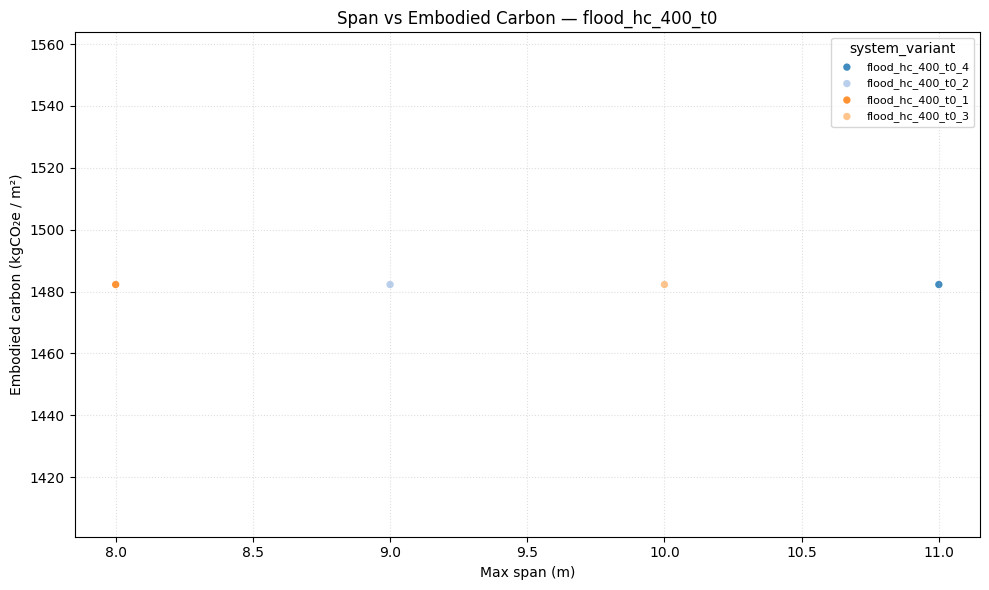

Plotted 4 points across 4 system_variant values for manufacturer='flood_hc_400_t0'.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# USER SETTINGS
# -----------------------
CSV_PATH = "summary_ranked_all.csv"   # <-- change to your csv path
MANUFACTURER = "flood_hc_400_t0"                 # <-- change to the manufacturer string you want
MAX_LEGEND_ITEMS = 25                 # set None for full legend (can get huge)

# -----------------------
# LOAD
# -----------------------
df = pd.read_csv("/Users/benjaminsalop/Desktop/Oxford/Research/edca/outputs/edca_run/summary_ranked_all.csv")

# -----------------------
# SCHEMA ALIASES (edit if your CSV uses different names)
# -----------------------
aliases = {
    "manufacturer": ["manufacturer", "mfr", "brand", "vendor", "supplier", "system_family"],
    "system_id": ["system_id", "system_variant", "variant_id", "system_variant_id", "system"],
    "span": ["max_span", "span", "span_m", "max_span_m", "span_max"],
    "carbon": ["carbon_per_m2", "ec_per_m2", "kgco2e_per_m2", "a1a5_kgco2e_m2", "embodied_carbon_per_m2", "carbon_total_kgCO2"],
}

def pick_col(df, canonical):
    for c in aliases[canonical]:
        if c in df.columns:
            return c
    raise KeyError(f"Missing column for '{canonical}'. Tried: {aliases[canonical]}\nAvailable: {list(df.columns)}")

mfr_col   = pick_col(df, "manufacturer")
id_col    = pick_col(df, "system_id")
span_col  = pick_col(df, "span")
carb_col  = pick_col(df, "carbon")

# -----------------------
# FILTER + CLEAN
# -----------------------
d = df.copy()
d[mfr_col] = d[mfr_col].astype(str).str.strip()

d = d[d[mfr_col].str.lower() == str(MANUFACTURER).strip().lower()].copy()
if d.empty:
    raise ValueError(f"No rows found for manufacturer={MANUFACTURER!r}. "
                     f"Check spelling/casing. Unique manufacturers (sample): {sorted(df[mfr_col].astype(str).unique())[:25]}")

d[span_col] = pd.to_numeric(d[span_col], errors="coerce")
d[carb_col] = pd.to_numeric(d[carb_col], errors="coerce")
d = d.dropna(subset=[span_col, carb_col, id_col])

# Optional: collapse exact duplicates (helps if your CSV repeats rows)
d = d.drop_duplicates(subset=[id_col, span_col, carb_col])

# -----------------------
# COLOR MAP BY system_id
# -----------------------
system_ids = d[id_col].astype(str)
uniq_ids = system_ids.unique()
n = len(uniq_ids)

# Map each system_id to an integer index
id_to_idx = {sid: i for i, sid in enumerate(uniq_ids)}
idx = system_ids.map(id_to_idx).to_numpy()

# Use a qualitative colormap if not too many IDs; otherwise continuous
cmap = plt.get_cmap("tab20" if n <= 20 else ("tab20b" if n <= 40 else "turbo"))

# -----------------------
# PLOT
# -----------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each system_id as its own series so legend is possible
for sid in uniq_ids:
    sub = d[system_ids == sid]
    ax.scatter(sub[span_col], sub[carb_col], s=28, alpha=0.85,
               color=cmap(id_to_idx[sid] % cmap.N),
               label=str(sid), edgecolors="none")

ax.set_title(f"Span vs Embodied Carbon — {MANUFACTURER}")
ax.set_xlabel("Max span (m)")
ax.set_ylabel("Embodied carbon (kgCO₂e / m²)")
ax.grid(True, linestyle=":", alpha=0.4)

# Legend control (avoid an unreadable wall of labels)
if MAX_LEGEND_ITEMS is None or n <= MAX_LEGEND_ITEMS:
    ax.legend(title=id_col, loc="best", fontsize=8)
else:
    # Show the top-N most frequent system_ids in the legend
    top_ids = (
        d[id_col].astype(str)
        .value_counts()
        .head(MAX_LEGEND_ITEMS)
        .index
        .tolist()
    )
    handles, labels = ax.get_legend_handles_labels()
    keep = [(h, l) for h, l in zip(handles, labels) if l in set(top_ids)]
    if keep:
        ax.legend([h for h, _ in keep], [l for _, l in keep],
                  title=f"{id_col} (top {MAX_LEGEND_ITEMS} by count)",
                  loc="best", fontsize=8)

plt.tight_layout()
plt.show()

print(f"Plotted {len(d)} points across {n} {id_col} values for manufacturer={MANUFACTURER!r}.")


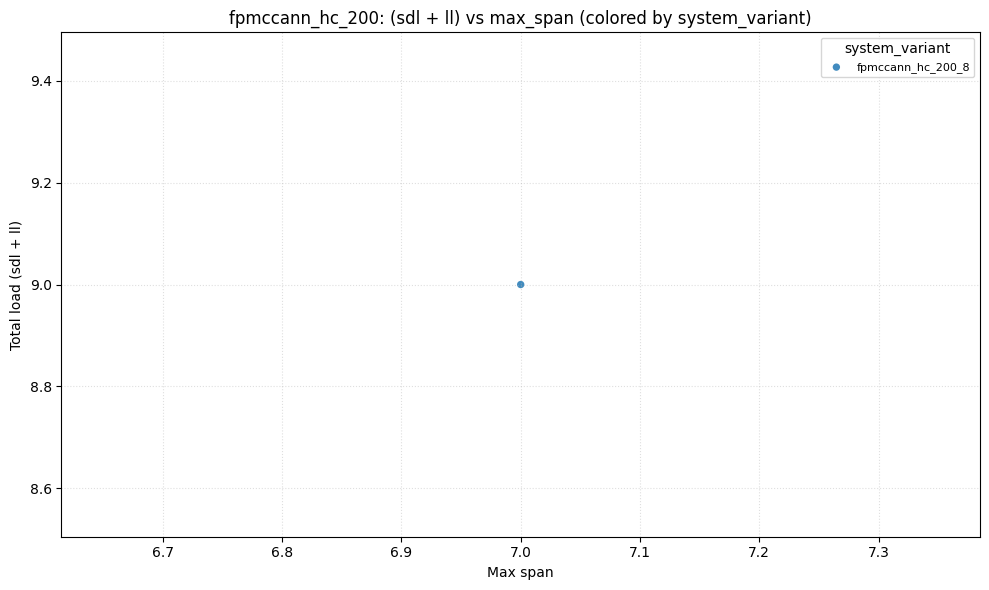

Plotted 1 points from system_family='fpmccann_hc_200' across 1 system_variant values.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# EDIT THESE
# -----------------------
CSV_PATH = "summary_ranked_all.csv"     # path to your CSV
MANUFACTURER = "fpmccann_hc_200"        # system_family you want
MFR_COL = "system_family"
ID_COL  = "system_variant"

X_COL = "max_span"   # x-axis
SDL_COL = "sdl"      # for y-axis sum
LL_COL  = "ll"

# -----------------------
# LOAD + FILTER
# -----------------------
df = pd.read_csv("/Users/benjaminsalop/Desktop/Oxford/Research/edca/outputs/edca_run/summary_ranked_all.csv")

# normalize strings
df[MFR_COL] = df[MFR_COL].astype(str).str.strip()
df[ID_COL]  = df[ID_COL].astype(str).str.strip()

# filter to manufacturer
d = df[df[MFR_COL].str.lower() == str(MANUFACTURER).strip().lower()].copy()
if d.empty:
    print("No rows found. Here are some system_family values (sample):")
    print(sorted(df[MFR_COL].dropna().astype(str).unique())[:40])
    raise ValueError(f"MANUFACTURER={MANUFACTURER!r} not found in {MFR_COL}")

# coerce numeric
for c in [X_COL, SDL_COL, LL_COL]:
    d[c] = pd.to_numeric(d[c], errors="coerce")

# compute total load
d["total_load"] = d[SDL_COL] + d[LL_COL]

# drop missing
d = d.dropna(subset=[X_COL, "total_load", ID_COL])

# optional: remove exact duplicates
d = d.drop_duplicates(subset=[ID_COL, X_COL, "total_load"])

# -----------------------
# PLOT
# -----------------------
system_ids = sorted(d[ID_COL].unique())
n = len(system_ids)
cmap = plt.get_cmap("tab20" if n <= 20 else ("tab20b" if n <= 40 else "turbo"))

fig, ax = plt.subplots(figsize=(10, 6))

for i, sid in enumerate(system_ids):
    sub = d[d[ID_COL] == sid].sort_values(X_COL)
    ax.scatter(
        sub[X_COL], sub["total_load"],
        s=28, alpha=0.85, edgecolors="none",
        color=cmap(i % cmap.N),
        label=sid
    )

ax.set_title(f"{MANUFACTURER}: (sdl + ll) vs {X_COL} (colored by {ID_COL})")
ax.set_xlabel("Max span")
ax.set_ylabel("Total load (sdl + ll)")
ax.grid(True, linestyle=":", alpha=0.4)

MAX_LEGEND = 25
if n <= MAX_LEGEND:
    ax.legend(title=ID_COL, loc="best", fontsize=8)
else:
    if ax.get_legend():
        ax.get_legend().remove()
    print(f"Legend suppressed ({n} {ID_COL} values). Set MAX_LEGEND higher if you want it.")

plt.tight_layout()
plt.show()

print(f"Plotted {len(d)} points from system_family={MANUFACTURER!r} across {n} {ID_COL} values.")


Found 15 manufacturers in column 'manufacturer'.


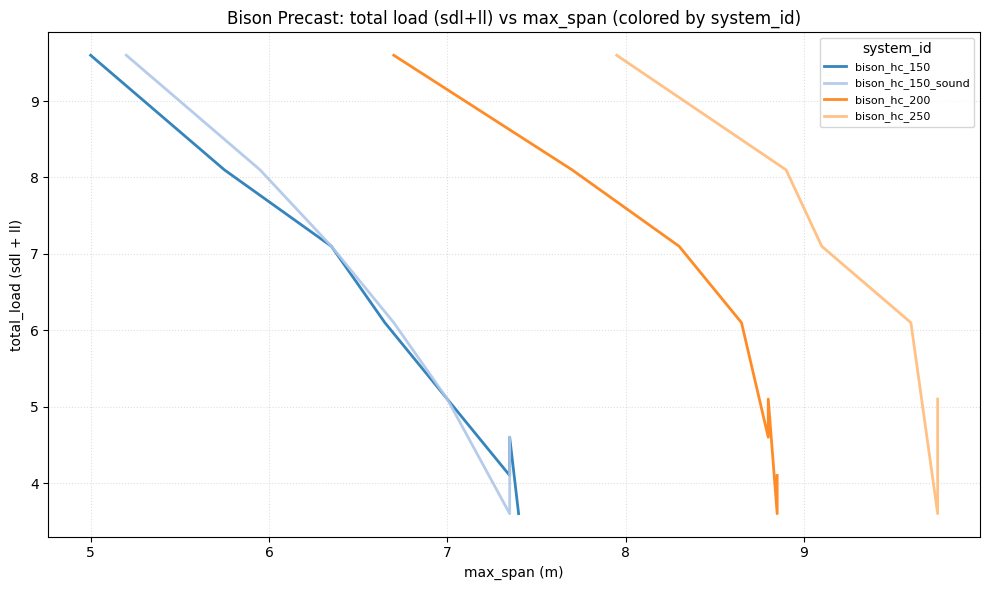

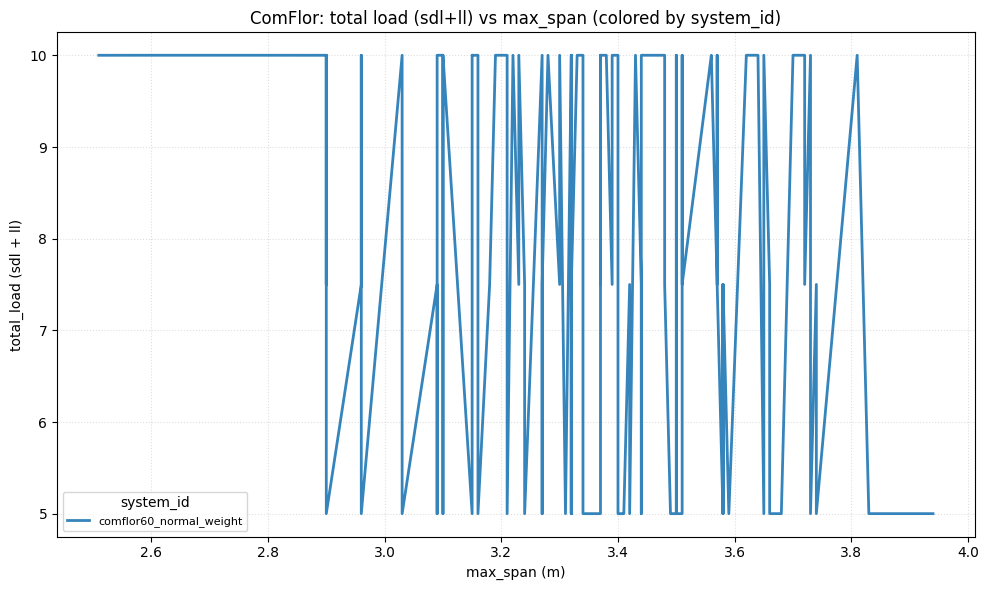

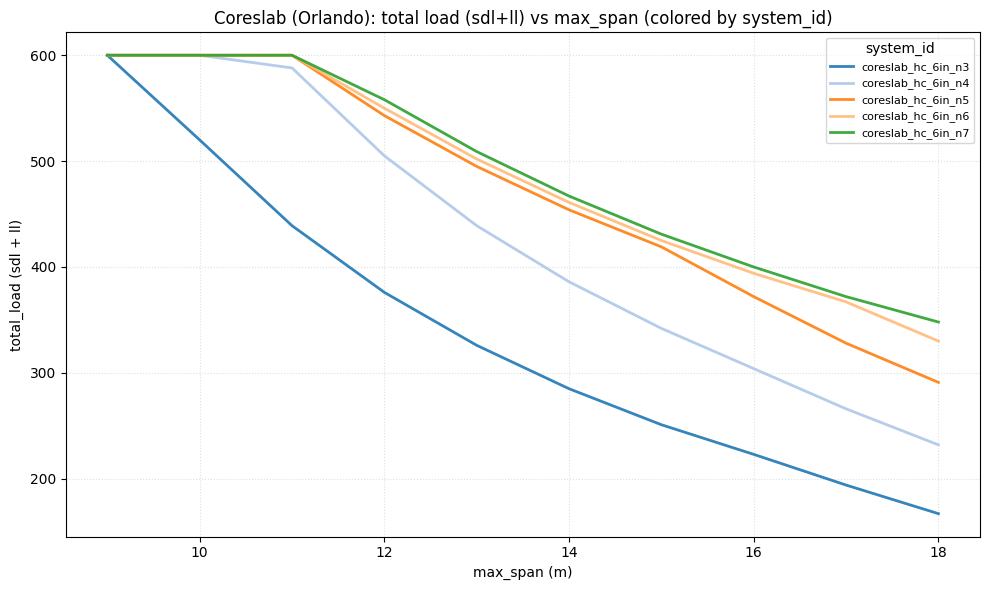

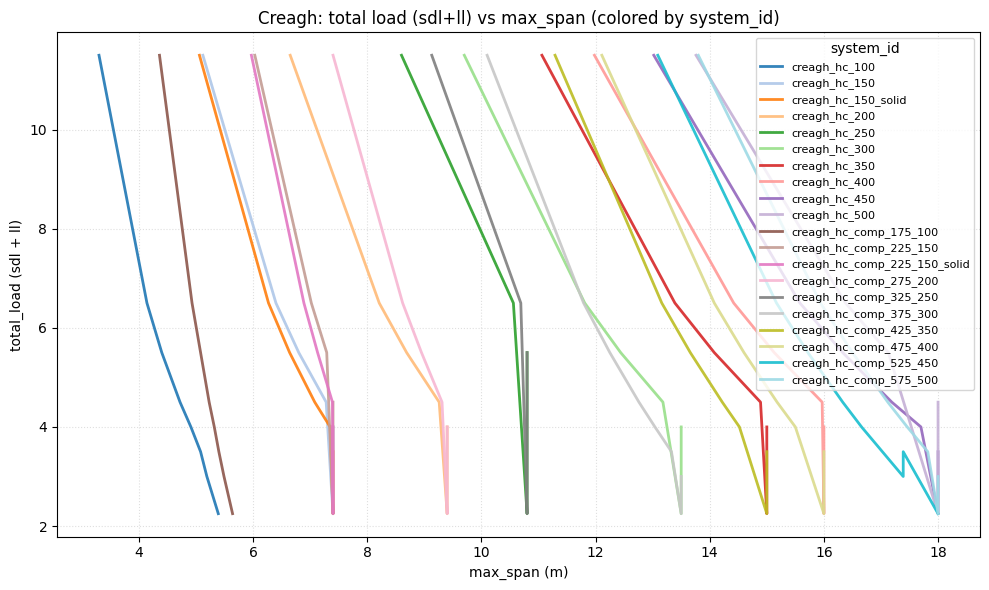

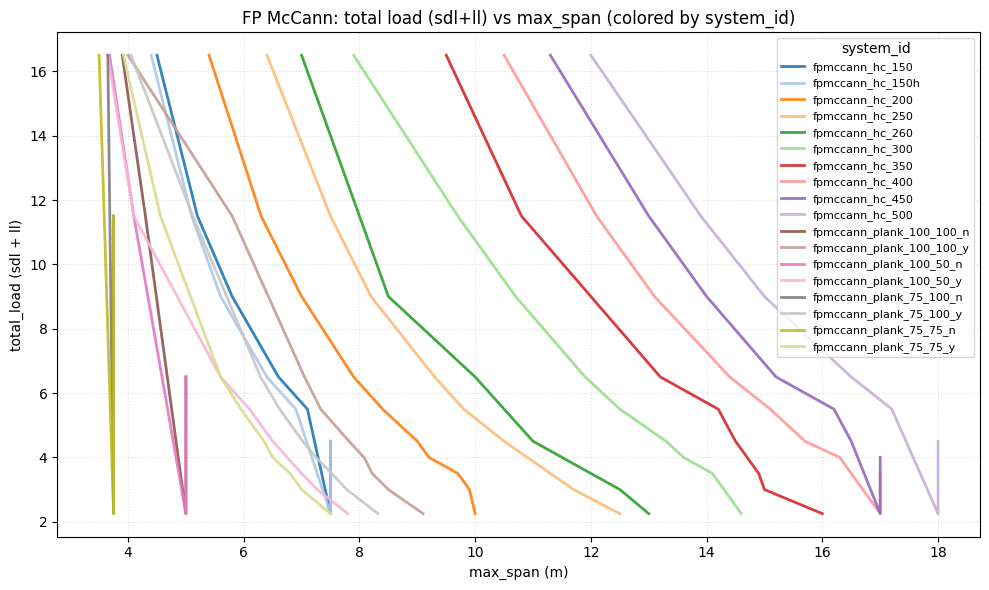

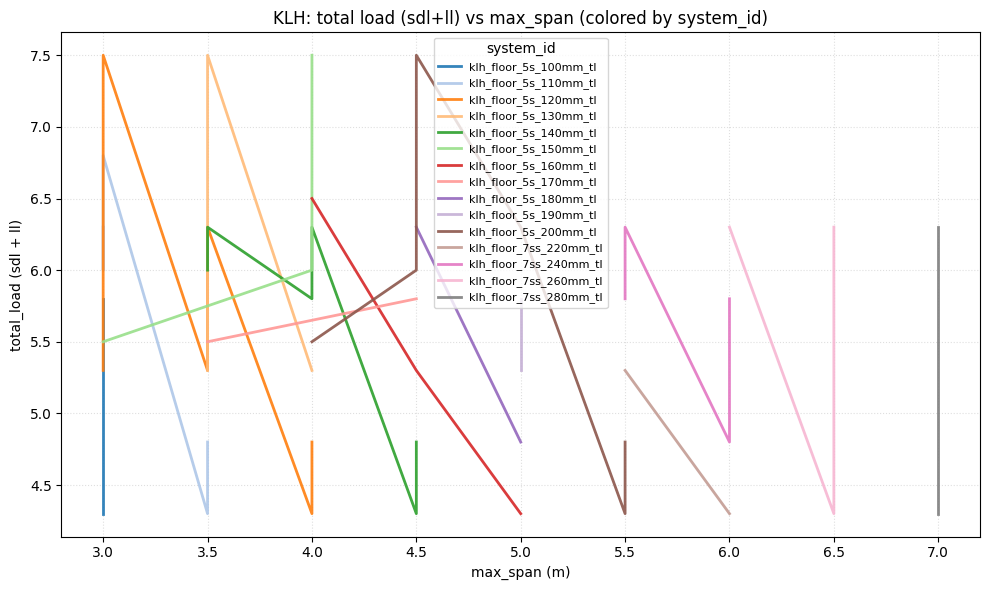

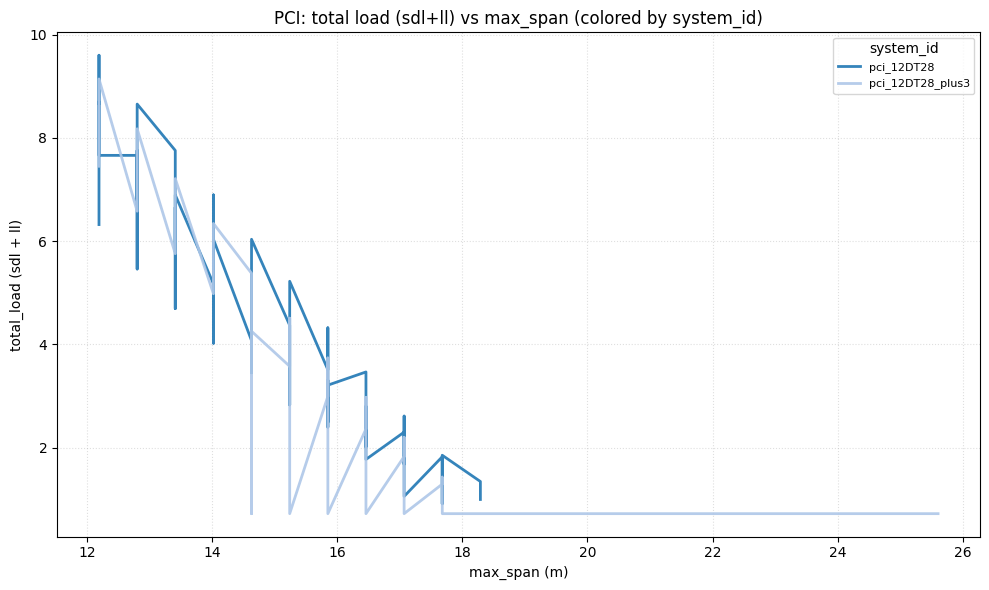

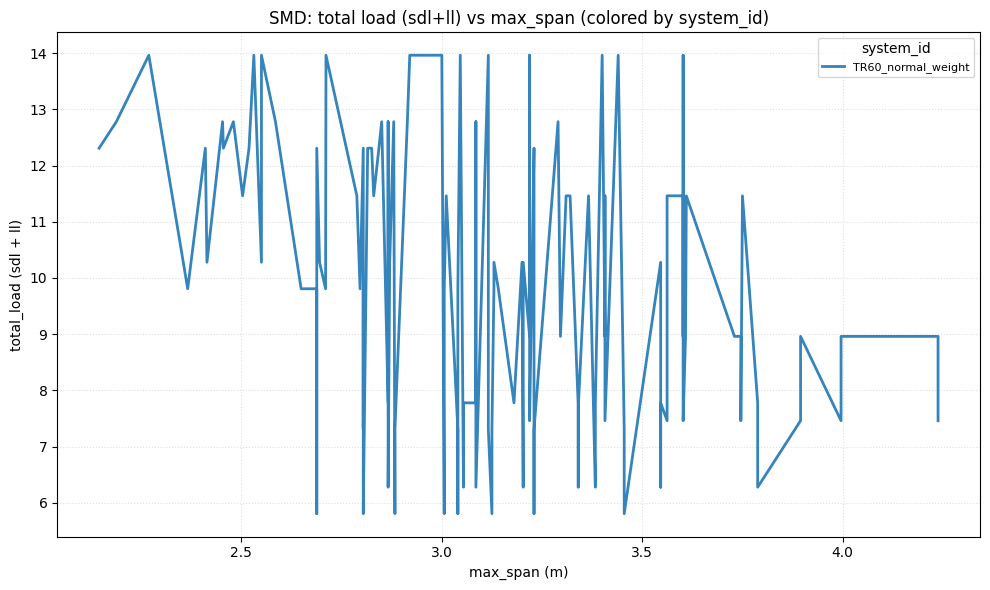

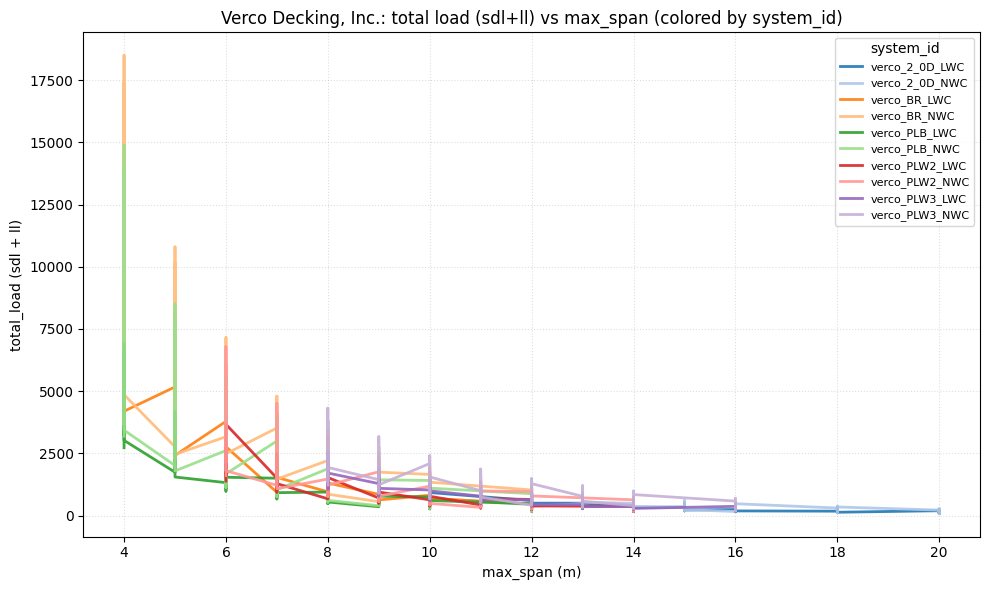

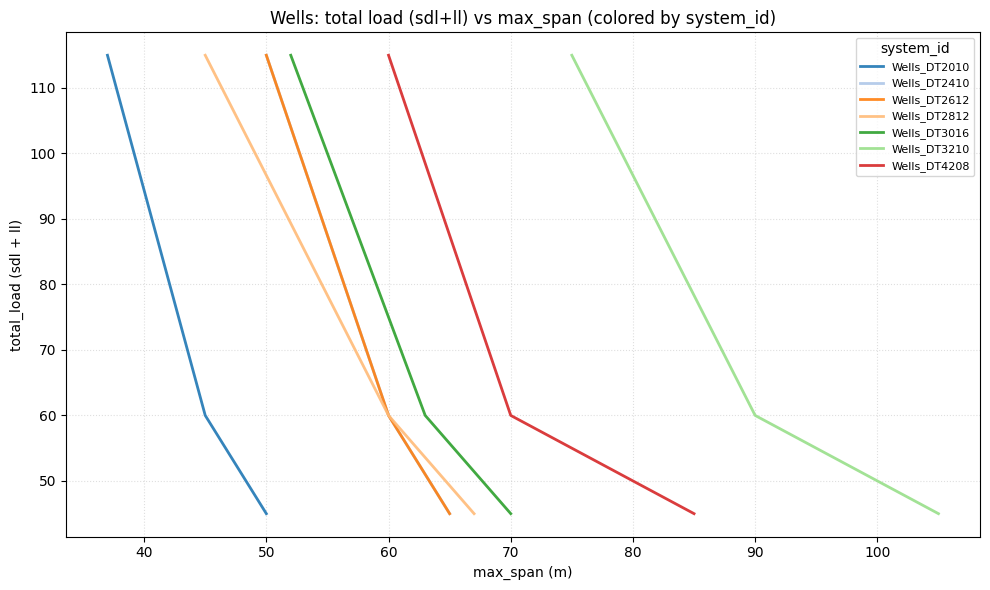

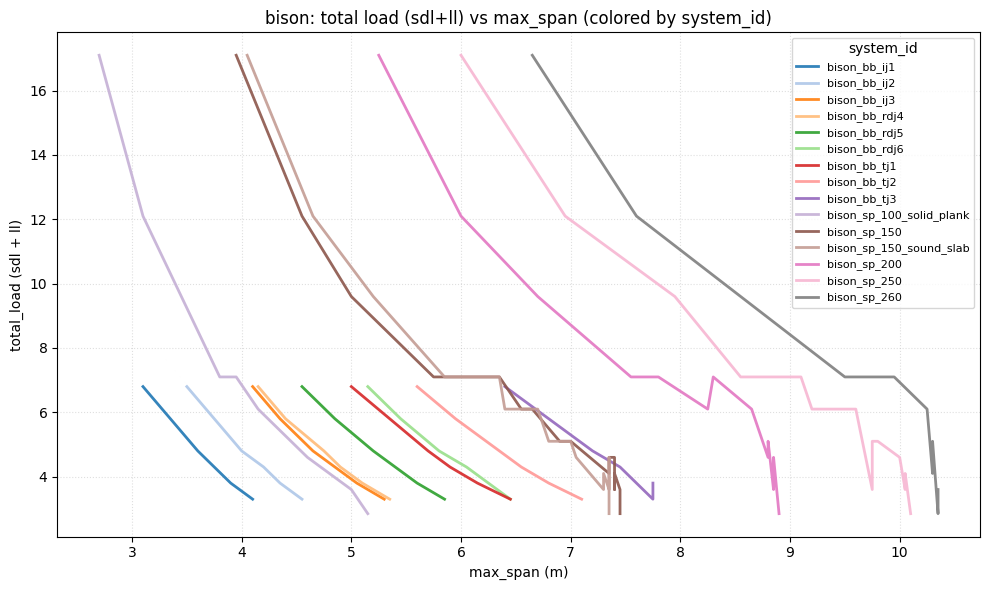

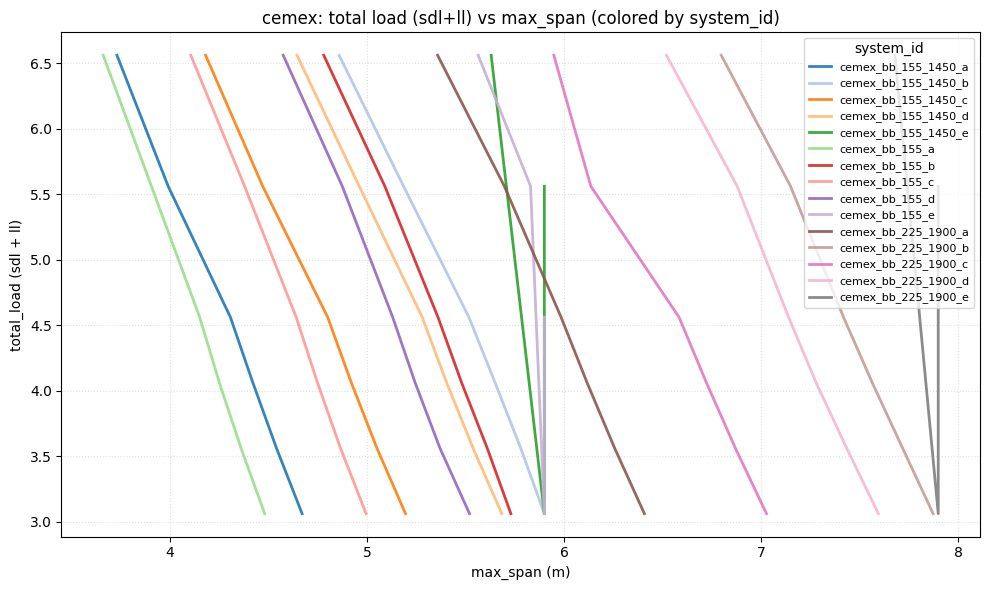

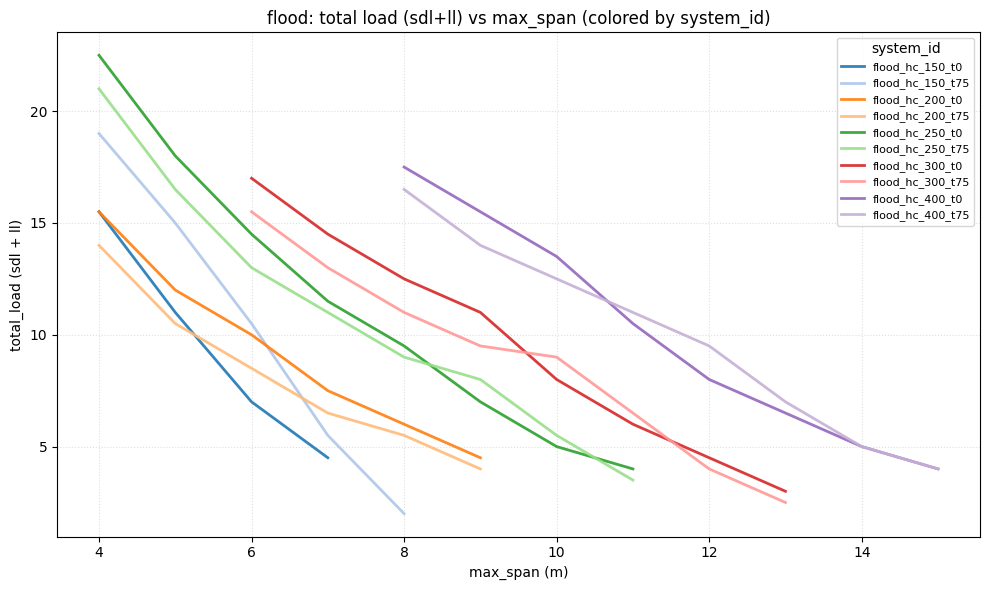

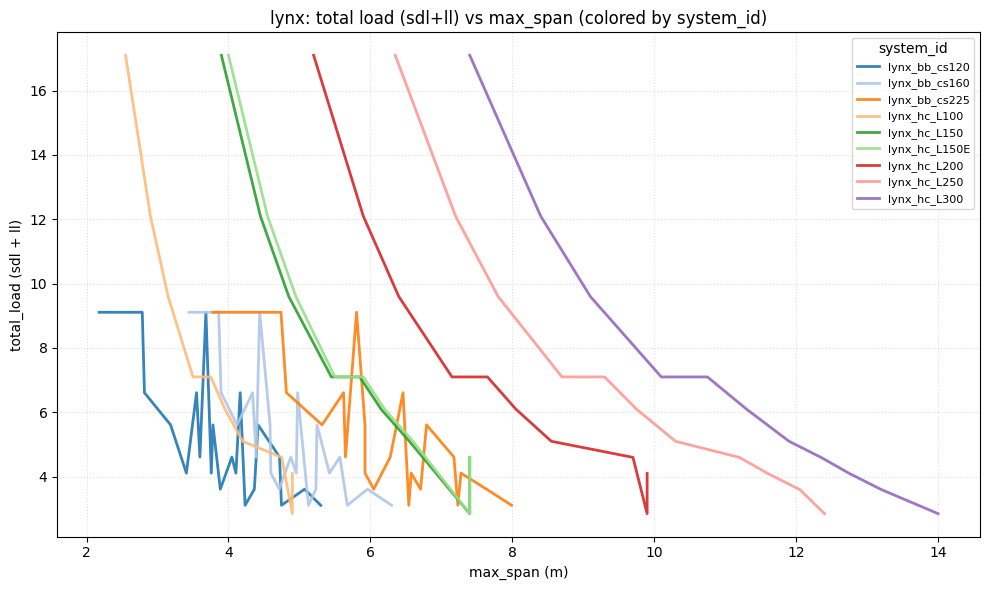

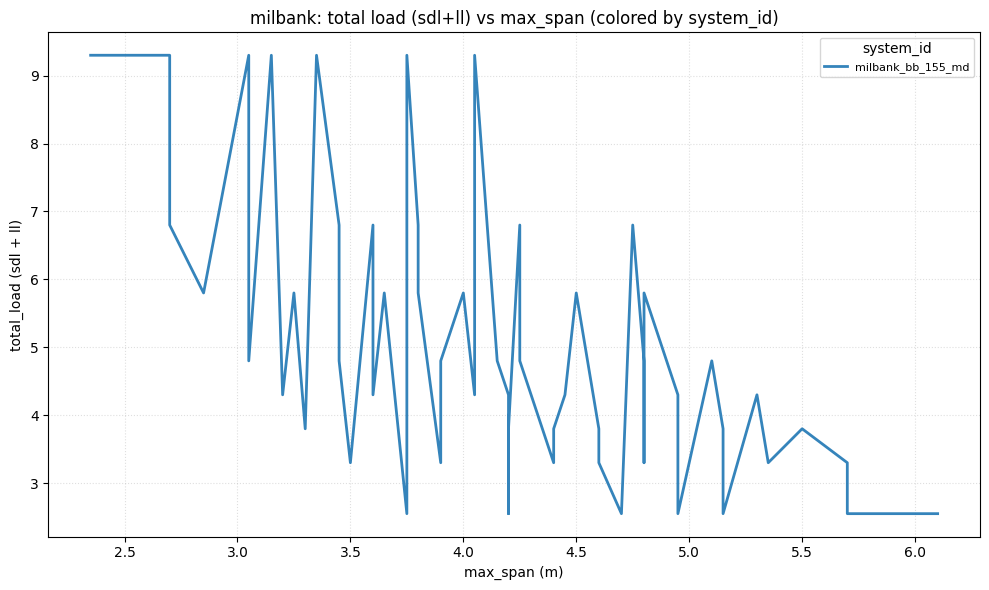

Done.


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------
# SETTINGS
# -----------------------
CSV_PATH = "systems.csv"         # <-- your systems.csv path
OUT_DIR = "manufacturer_plots"   # folder to save figures; set None to not save
SHOW = True                      # show plots inline
MAX_LEGEND = 25                  # cap legend size (set None for full legend)

# NEW OPTIONS:
CONNECT_LINES = True             # connect points for each system_id
SHOW_POINTS = False               # show scatter markers
LINE_WIDTH = 2.0                 # line thickness (if CONNECT_LINES)
POINT_SIZE = 28                  # marker size (if SHOW_POINTS)
ALPHA = 0.9                      # point/line alpha

# -----------------------
# LOAD
# -----------------------
df = pd.read_csv("/Users/benjaminsalop/Desktop/Oxford/Research/edca/inputs/source/presets/systems/systems.csv")

# -----------------------
# COLUMN PICKER (aliases)
# -----------------------
ALIASES = {
    "manufacturer": ["manufacturer", "system_family", "brand", "vendor", "supplier"],
    "system_id": ["system_id", "system_variant", "variant_id", "system_variant_id", "system"],
    "max_span": ["max_span", "max_span_m", "span_max", "span_m", "span"],
    "sdl": ["sdl", "SDL", "dead_load", "sdl_total", "sdl_total_kn_m2"],
    "ll": ["ll", "LL", "live_load", "imposed_load", "ll_total_kn_m2"],
}

def pick_col(df, key):
    for c in ALIASES[key]:
        if c in df.columns:
            return c
    raise KeyError(
        f"Missing column for '{key}'. Tried: {ALIASES[key]}\nAvailable: {list(df.columns)}"
    )

mfr_col  = pick_col(df, "manufacturer")
id_col   = pick_col(df, "system_id")
span_col = pick_col(df, "max_span")
sdl_col  = pick_col(df, "sdl")
ll_col   = pick_col(df, "ll")

# -----------------------
# CLEAN + COMPUTE
# -----------------------
d = df.copy()
d[mfr_col] = d[mfr_col].astype(str).str.strip()
d[id_col]  = d[id_col].astype(str).str.strip()

d[span_col] = pd.to_numeric(d[span_col], errors="coerce")
d[sdl_col]  = pd.to_numeric(d[sdl_col], errors="coerce")
d[ll_col]   = pd.to_numeric(d[ll_col], errors="coerce")

d["total_load"] = d[sdl_col] + d[ll_col]
d = d.dropna(subset=[mfr_col, id_col, span_col, "total_load"])

# optional: remove exact duplicates
d = d.drop_duplicates(subset=[mfr_col, id_col, span_col, "total_load"])

# -----------------------
# PLOTTING (one plot per manufacturer)
# -----------------------
if OUT_DIR:
    Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

manufacturers = sorted(d[mfr_col].unique())
print(f"Found {len(manufacturers)} manufacturers in column '{mfr_col}'.")

for mfr in manufacturers:
    sub = d[d[mfr_col] == mfr].copy()
    if sub.empty:
        continue

    system_ids = sorted(sub[id_col].unique())
    n = len(system_ids)

    cmap = plt.get_cmap("tab20" if n <= 20 else ("tab20b" if n <= 40 else "turbo"))

    fig, ax = plt.subplots(figsize=(10, 6))

    for i, sid in enumerate(system_ids):
        ss = sub[sub[id_col] == sid].copy()
        ss = ss.sort_values(span_col)

        color = cmap(i % cmap.N)

        # optional: line connecting curve
        if CONNECT_LINES:
            ax.plot(
                ss[span_col],
                ss["total_load"],
                linewidth=LINE_WIDTH,
                alpha=ALPHA,
                color=color,
                label=str(sid)  # label on the line so legend still works if points hidden
            )

            # If also showing points, don't duplicate legend entries
            label_for_points = None
        else:
            label_for_points = str(sid)

        # optional: points
        if SHOW_POINTS:
            ax.scatter(
                ss[span_col],
                ss["total_load"],
                s=POINT_SIZE,
                alpha=ALPHA,
                edgecolors="none",
                color=color,
                label=label_for_points
            )

    ax.set_title(f"{mfr}: total load (sdl+ll) vs {span_col} (colored by {id_col})")
    ax.set_xlabel(f"{span_col} (m)" if "span" in span_col.lower() else span_col)
    ax.set_ylabel("total_load (sdl + ll)")
    ax.grid(True, linestyle=":", alpha=0.4)

    # legend handling
    if MAX_LEGEND is None or n <= MAX_LEGEND:
        ax.legend(title=id_col, loc="best", fontsize=8)
    else:
        top_ids = sub[id_col].value_counts().head(MAX_LEGEND).index.tolist()
        handles, labels = ax.get_legend_handles_labels()
        keep = [(h, l) for h, l in zip(handles, labels) if l in set(map(str, top_ids))]
        if keep:
            ax.legend([h for h, _ in keep], [l for _, l in keep],
                      title=f"{id_col} (top {MAX_LEGEND})",
                      loc="best", fontsize=8)

    plt.tight_layout()

    if OUT_DIR:
        safe = "".join(ch if ch.isalnum() or ch in ("_", "-", ".") else "_" for ch in str(mfr))
        fig.savefig(Path(OUT_DIR) / f"{safe}_total_load_vs_span.png", dpi=200)

    if SHOW:
        plt.show()
    else:
        plt.close(fig)

print("Done.")

Filter applied: span <= 15.0 m and total_load <= 25.0 kN/m² (2278 -> 1136 rows).


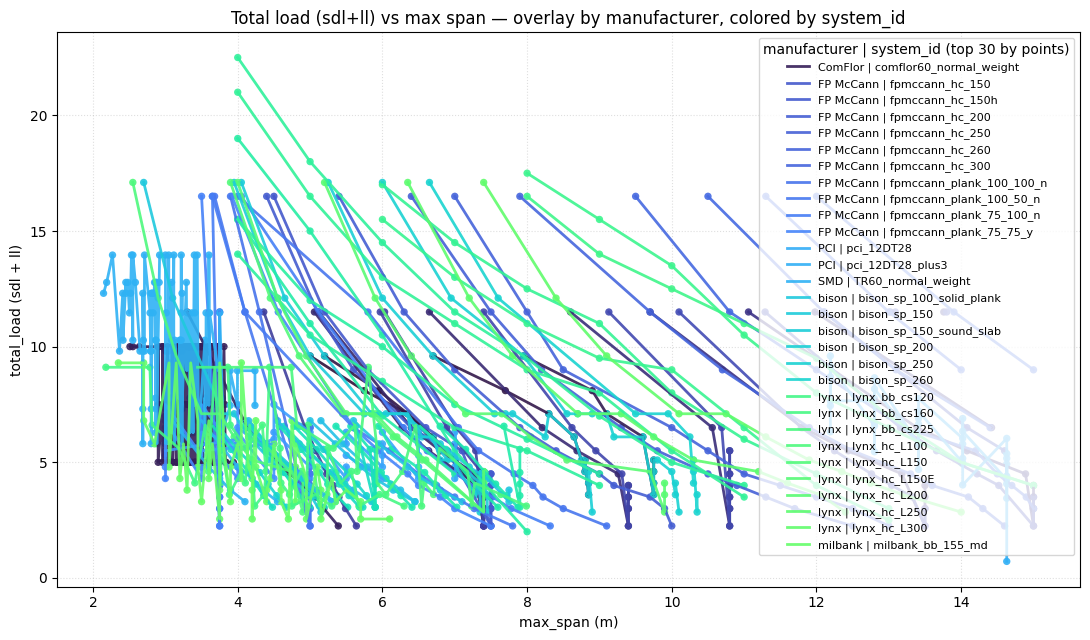

Plotted 1136 points across 111 curves for manufacturers=['Bison Precast', 'ComFlor', 'Coreslab (Orlando)', 'Creagh', 'Dura-Stress', 'FP McCann', 'Flood Precast', 'KLH', 'Metsa', 'PCI', 'Precast Flooring Federation members', 'SMD', 'Tata', 'TiltUp', 'Verco Decking, Inc.', 'Vulcraft', 'Wells', 'bison', 'cemex', 'flood', 'lynx', 'milbank'].


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------
# SETTINGS
# -----------------------
CSV_PATH = "/Users/benjaminsalop/Desktop/Oxford/Research/edca/inputs/source/presets/systems/systems.csv"

# List the manufacturers (system_family) you want on the same plot:
MANUFACTURERS = ['Bison Precast', 'ComFlor', 'Coreslab (Orlando)', 'Creagh', 'Dura-Stress', 'FP McCann', 'Flood Precast', 'KLH', 'Metsa', 'PCI', 'Precast Flooring Federation members', 'SMD', 'Tata', 'TiltUp', 'Verco Decking, Inc.', 'Vulcraft', 'Wells', 'bison', 'cemex', 'flood', 'lynx', 'milbank']

# Plot controls
CONNECT_LINES = True
SHOW_POINTS = True
LINE_WIDTH = 2.0
POINT_SIZE = 28
ALPHA = 0.9

# Legend controls
MAX_LEGEND = 30     # set None for full legend (can get huge)

# Save/show
SAVEFIG = None      # e.g. "overlay_manufacturers.png" or None
SHOW = True

# -----------------------
# LOAD
# -----------------------
df = pd.read_csv(CSV_PATH)

# -----------------------
# COLUMN PICKER (aliases)
# -----------------------
ALIASES = {
    "manufacturer": ["manufacturer", "system_family", "brand", "vendor", "supplier"],
    "system_id": ["system_id", "system_variant", "variant_id", "system_variant_id", "system"],
    "max_span": ["max_span", "max_span_m", "span_max", "span_m", "span"],
    "sdl": ["sdl", "SDL", "dead_load", "sdl_total", "sdl_total_kn_m2"],
    "ll": ["ll", "LL", "live_load", "imposed_load", "ll_total_kn_m2"],
}

def pick_col(df, key):
    for c in ALIASES[key]:
        if c in df.columns:
            return c
    raise KeyError(
        f"Missing column for '{key}'. Tried: {ALIASES[key]}\nAvailable: {list(df.columns)}"
    )

mfr_col  = pick_col(df, "manufacturer")
id_col   = pick_col(df, "system_id")
span_col = pick_col(df, "max_span")
sdl_col  = pick_col(df, "sdl")
ll_col   = pick_col(df, "ll")

# -----------------------
# CLEAN + COMPUTE
# -----------------------
d = df.copy()
d[mfr_col] = d[mfr_col].astype(str).str.strip()
d[id_col]  = d[id_col].astype(str).str.strip()

d[span_col] = pd.to_numeric(d[span_col], errors="coerce")
d[sdl_col]  = pd.to_numeric(d[sdl_col], errors="coerce")
d[ll_col]   = pd.to_numeric(d[ll_col], errors="coerce")

d["total_load"] = d[sdl_col] + d[ll_col]
d = d.dropna(subset=[mfr_col, id_col, span_col, "total_load"])


# Filter to selected manufacturers
want = [str(x).strip().lower() for x in MANUFACTURERS]
d = d[d[mfr_col].str.lower().isin(want)].copy()

if d.empty:
    print("No rows found for given MANUFACTURERS.")
    print("Available manufacturers (sample):")
    print(sorted(df[mfr_col].dropna().astype(str).unique())[:40])
    raise ValueError("MANUFACTURERS filter produced empty dataframe.")

# optional: remove exact duplicates
d = d.drop_duplicates(subset=[mfr_col, id_col, span_col, "total_load"])

# -----------------------
# FILTERS (requested)
# -----------------------
MAX_SPAN_LIMIT_M = 15.0
MAX_LOAD_LIMIT_KN_M2 = 25.0

before = len(d)

d = d[
    (d[span_col] <= MAX_SPAN_LIMIT_M) &
    (d["total_load"] <= MAX_LOAD_LIMIT_KN_M2)
].copy()

after = len(d)
print(f"Filter applied: span <= {MAX_SPAN_LIMIT_M} m and total_load <= {MAX_LOAD_LIMIT_KN_M2} kN/m² "
      f"({before} -> {after} rows).")

if d.empty:
    raise ValueError("All rows were filtered out. Loosen limits or check units/columns.")


# -----------------------
# PLOT (overlay)
# -----------------------
# Each curve is uniquely identified by (manufacturer, system_id)
d["_curve_id"] = d[mfr_col].astype(str) + " | " + d[id_col].astype(str)
curve_ids = sorted(d["_curve_id"].unique())
n = len(curve_ids)

cmap = plt.get_cmap("tab20" if n <= 20 else ("tab20b" if n <= 40 else "turbo"))

fig, ax = plt.subplots(figsize=(11, 6.5))

for i, cid in enumerate(curve_ids):
    ss = d[d["_curve_id"] == cid].sort_values(span_col)
    color = cmap(i % cmap.N)

    # line
    if CONNECT_LINES:
        ax.plot(
            ss[span_col],
            ss["total_load"],
            linewidth=LINE_WIDTH,
            alpha=ALPHA,
            color=color,
            label=cid
        )
        label_points = None  # avoid duplicate legend entry
    else:
        label_points = cid

    # points
    if SHOW_POINTS:
        ax.scatter(
            ss[span_col],
            ss["total_load"],
            s=POINT_SIZE,
            alpha=ALPHA,
            edgecolors="none",
            color=color,
            label=label_points
        )


ax.set_title("Total load (sdl+ll) vs max span — overlay by manufacturer, colored by system_id")
ax.set_xlabel(f"{span_col} (m)" if "span" in span_col.lower() else span_col)
ax.set_ylabel("total_load (sdl + ll)")
ax.grid(True, linestyle=":", alpha=0.4)

# Legend management
if MAX_LEGEND is None or n <= MAX_LEGEND:
    ax.legend(title=f"{mfr_col} | {id_col}", loc="best", fontsize=8)
else:
    # Keep only top-N curves by point count
    counts = d["_curve_id"].value_counts()
    keep = set(counts.head(MAX_LEGEND).index.tolist())
    handles, labels = ax.get_legend_handles_labels()
    keep_pairs = [(h, l) for h, l in zip(handles, labels) if l in keep]
    if keep_pairs:
        ax.legend([h for h, _ in keep_pairs], [l for _, l in keep_pairs],
                  title=f"{mfr_col} | {id_col} (top {MAX_LEGEND} by points)",
                  loc="best", fontsize=8)

plt.tight_layout()

if SAVEFIG:
    fig.savefig(SAVEFIG, dpi=220)

if SHOW:
    plt.show()
else:
    plt.close(fig)

print(f"Plotted {len(d)} points across {n} curves for manufacturers={MANUFACTURERS}.")


Filter applied: 44 -> 44 rows (span <= 15.0 m, swt <= 200.0)


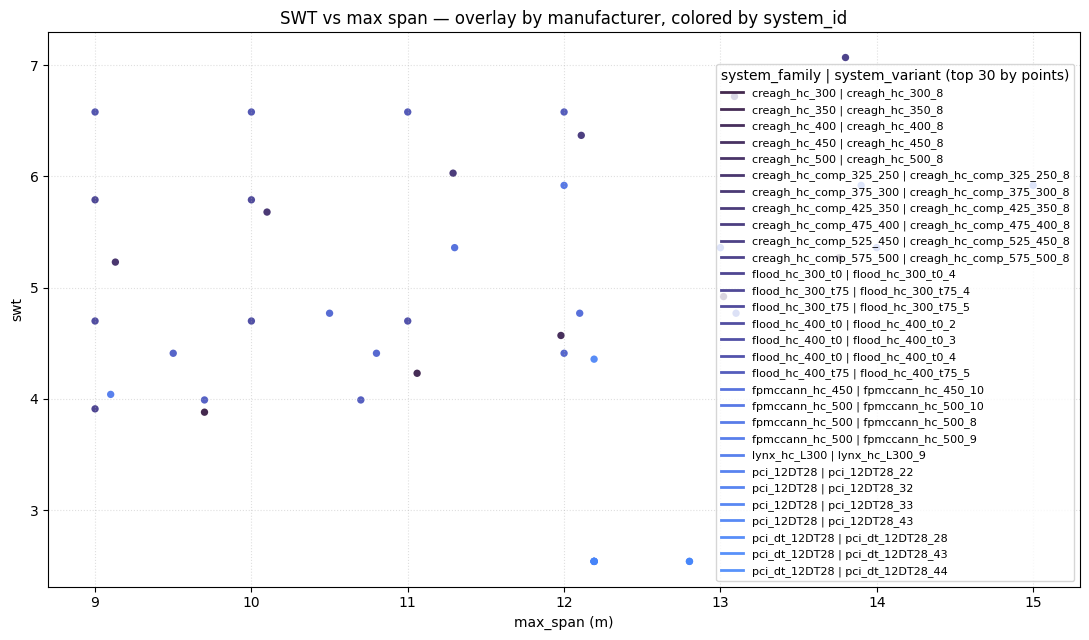

Plotted 44 points across 44 curves.


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# SETTINGS
# -----------------------
CSV_PATH = "/Users/benjaminsalop/Desktop/Oxford/Research/edca/outputs/edca_run/candidates_span_9.00m.csv"

# Plot controls
CONNECT_LINES = True
SHOW_POINTS = True
LINE_WIDTH = 2.0
POINT_SIZE = 28
ALPHA = 0.9

# Legend controls
MAX_LEGEND = 30     # set None for full legend (can get huge)

# Save/show
SAVEFIG = None      # e.g. "swt_vs_span_overlay.png" or None
SHOW = True

# Filters
MAX_SPAN_LIMIT_M = 15.0
MAX_SWT_LIMIT = 200.0   # set None to disable

# -----------------------
# LOAD
# -----------------------
df = pd.read_csv(CSV_PATH)

# -----------------------
# COLUMN PICKER (aliases)
# -----------------------
ALIASES = {
    "manufacturer": ["manufacturer", "system_family", "brand", "vendor", "supplier"],
    "system_id": ["system_id", "system_variant", "variant_id", "system_variant_id", "system"],
    "max_span": ["max_span", "max_span_m", "span_max", "span_m", "span"],
    "swt": ["swt", "self_weight_total", "self_weight", "superimposed_weight_total"],
}

def pick_col(df, key):
    for c in ALIASES[key]:
        if c in df.columns:
            return c
    raise KeyError(f"Missing column for '{key}'. Tried: {ALIASES[key]}\nAvailable: {list(df.columns)}")

mfr_col  = pick_col(df, "manufacturer")
id_col   = pick_col(df, "system_id")
span_col = pick_col(df, "max_span")
swt_col  = pick_col(df, "swt")

# -----------------------
# CLEAN
# -----------------------
d = df.copy()
d[mfr_col] = d[mfr_col].astype(str).str.strip()
d[id_col]  = d[id_col].astype(str).str.strip()

d[span_col] = pd.to_numeric(d[span_col], errors="coerce")
d[swt_col]  = pd.to_numeric(d[swt_col], errors="coerce")

d = d.dropna(subset=[mfr_col, id_col, span_col, swt_col])
d = d.drop_duplicates(subset=[mfr_col, id_col, span_col, swt_col])

# -----------------------
# FILTERS
# -----------------------
before = len(d)
mask = (d[span_col] <= MAX_SPAN_LIMIT_M)
if MAX_SWT_LIMIT is not None:
    mask &= (d[swt_col] <= MAX_SWT_LIMIT)

d = d[mask].copy()
after = len(d)
print(f"Filter applied: {before} -> {after} rows "
      f"(span <= {MAX_SPAN_LIMIT_M} m"
      f"{'' if MAX_SWT_LIMIT is None else f', swt <= {MAX_SWT_LIMIT}'})")

if d.empty:
    raise ValueError("All rows were filtered out. Loosen limits or check units/columns.")

# -----------------------
# PLOT (overlay)
# -----------------------
# curve = manufacturer | system_id
d["_curve_id"] = d[mfr_col].astype(str) + " | " + d[id_col].astype(str)
curve_ids = sorted(d["_curve_id"].unique())
n = len(curve_ids)

cmap = plt.get_cmap("tab20" if n <= 20 else ("tab20b" if n <= 40 else "turbo"))

fig, ax = plt.subplots(figsize=(11, 6.5))

for i, cid in enumerate(curve_ids):
    ss = d[d["_curve_id"] == cid].sort_values(span_col)
    color = cmap(i % cmap.N)

    # line
    if CONNECT_LINES:
        ax.plot(
            ss[span_col],
            ss[swt_col],
            linewidth=LINE_WIDTH,
            alpha=ALPHA,
            color=color,
            label=cid
        )
        label_points = None
    else:
        label_points = cid

    # points
    if SHOW_POINTS:
        ax.scatter(
            ss[span_col],
            ss[swt_col],
            s=POINT_SIZE,
            alpha=ALPHA,
            edgecolors="none",
            color=color,
            label=label_points
        )

ax.set_title("SWT vs max span — overlay by manufacturer, colored by system_id")
ax.set_xlabel(f"{span_col} (m)" if "span" in span_col.lower() else span_col)
ax.set_ylabel(swt_col)
ax.grid(True, linestyle=":", alpha=0.4)

# Legend management
if MAX_LEGEND is None or n <= MAX_LEGEND:
    ax.legend(title=f"{mfr_col} | {id_col}", loc="best", fontsize=8)
else:
    counts = d["_curve_id"].value_counts()
    keep = set(counts.head(MAX_LEGEND).index.tolist())
    handles, labels = ax.get_legend_handles_labels()
    keep_pairs = [(h, l) for h, l in zip(handles, labels) if l in keep]
    if keep_pairs:
        ax.legend([h for h, _ in keep_pairs], [l for _, l in keep_pairs],
                  title=f"{mfr_col} | {id_col} (top {MAX_LEGEND} by points)",
                  loc="best", fontsize=8)

plt.tight_layout()

if SAVEFIG:
    fig.savefig(SAVEFIG, dpi=220)

if SHOW:
    plt.show()
else:
    plt.close(fig)

print(f"Plotted {len(d)} points across {n} curves.")


In [5]:
import re

# ============================================================
# 1) PASTE RAW LISTS HERE (exactly as copied from your CSV/text)
#    They will become Python lists automatically.
# ============================================================

raw_variants_above = """
ComFlor80_single_unpropped_FR1.0_SD140_MA142_G0.9
ComFlor80_single_unpropped_FR1.0_SD140_MA142_G0.9
ComFlor80_single_unpropped_FR1.0_SD140_MA142_G0.9
ComFlor80_single_unpropped_FR1.0_SD140_MA142_G1.0
ComFlor80_single_unpropped_FR1.0_SD140_MA142_G1.0
ComFlor80_single_unpropped_FR1.0_SD140_MA142_G1.0
ComFlor80_single_unpropped_FR1.0_SD140_MA142_G1.2
ComFlor80_single_unpropped_FR1.0_SD140_MA142_G1.2
ComFlor80_single_unpropped_FR1.0_SD140_MA142_G1.2
ComFlor80_single_unpropped_FR1.0_SD150_MA142_G0.9
ComFlor80_single_unpropped_FR1.0_SD150_MA142_G0.9
ComFlor80_single_unpropped_FR1.0_SD150_MA142_G0.9
ComFlor80_single_unpropped_FR1.0_SD150_MA142_G1.0
ComFlor80_single_unpropped_FR1.0_SD150_MA142_G1.0
ComFlor80_single_unpropped_FR1.0_SD150_MA142_G1.0
ComFlor80_single_unpropped_FR1.0_SD150_MA142_G1.2
ComFlor80_single_unpropped_FR1.0_SD150_MA142_G1.2
ComFlor80_single_unpropped_FR1.0_SD150_MA142_G1.2
ComFlor80_single_unpropped_FR1.0_SD160_MA193_G0.9
ComFlor80_single_unpropped_FR1.0_SD160_MA193_G0.9
ComFlor80_single_unpropped_FR1.0_SD160_MA193_G0.9
ComFlor80_single_unpropped_FR1.0_SD160_MA193_G1.0
ComFlor80_single_unpropped_FR1.0_SD160_MA193_G1.0
ComFlor80_single_unpropped_FR1.0_SD160_MA193_G1.0
ComFlor80_single_unpropped_FR1.0_SD160_MA193_G1.2
ComFlor80_single_unpropped_FR1.0_SD160_MA193_G1.2
ComFlor80_single_unpropped_FR1.0_SD160_MA193_G1.2
ComFlor80_single_unpropped_FR1.0_SD170_MA193_G0.9
ComFlor80_single_unpropped_FR1.0_SD170_MA193_G0.9
ComFlor80_single_unpropped_FR1.0_SD170_MA193_G0.9
ComFlor80_single_unpropped_FR1.0_SD170_MA193_G1.0
ComFlor80_single_unpropped_FR1.0_SD170_MA193_G1.0
ComFlor80_single_unpropped_FR1.0_SD170_MA193_G1.0
ComFlor80_single_unpropped_FR1.0_SD170_MA193_G1.2
ComFlor80_single_unpropped_FR1.0_SD170_MA193_G1.2
ComFlor80_single_unpropped_FR1.0_SD170_MA193_G1.2
ComFlor80_single_unpropped_FR1.0_SD180_MA252_G0.9
ComFlor80_single_unpropped_FR1.0_SD180_MA252_G0.9
ComFlor80_single_unpropped_FR1.0_SD180_MA252_G0.9
ComFlor80_single_unpropped_FR1.0_SD180_MA252_G1.0
ComFlor80_single_unpropped_FR1.0_SD180_MA252_G1.0
ComFlor80_single_unpropped_FR1.0_SD180_MA252_G1.0
ComFlor80_single_unpropped_FR1.0_SD180_MA252_G1.2
ComFlor80_single_unpropped_FR1.0_SD180_MA252_G1.2
ComFlor80_single_unpropped_FR1.0_SD180_MA252_G1.2
ComFlor80_single_unpropped_FR1.0_SD190_MA252_G0.9
ComFlor80_single_unpropped_FR1.0_SD190_MA252_G0.9
ComFlor80_single_unpropped_FR1.0_SD190_MA252_G0.9
ComFlor80_single_unpropped_FR1.0_SD190_MA252_G1.0
ComFlor80_single_unpropped_FR1.0_SD190_MA252_G1.0
ComFlor80_single_unpropped_FR1.0_SD190_MA252_G1.0
ComFlor80_single_unpropped_FR1.0_SD190_MA252_G1.2
ComFlor80_single_unpropped_FR1.0_SD190_MA252_G1.2
ComFlor80_single_unpropped_FR1.0_SD190_MA252_G1.2
ComFlor80_single_unpropped_FR1.0_SD200_MA252_G0.9
ComFlor80_single_unpropped_FR1.0_SD200_MA252_G0.9
ComFlor80_single_unpropped_FR1.0_SD200_MA252_G0.9
ComFlor80_single_unpropped_FR1.0_SD200_MA252_G1.0
ComFlor80_single_unpropped_FR1.0_SD200_MA252_G1.0
ComFlor80_single_unpropped_FR1.0_SD200_MA252_G1.0
ComFlor80_single_unpropped_FR1.0_SD200_MA252_G1.2
ComFlor80_single_unpropped_FR1.0_SD200_MA252_G1.2
ComFlor80_single_unpropped_FR1.0_SD200_MA252_G1.2
ComFlor80_single_unpropped_FR1.5_SD150_MA142_G0.9
ComFlor80_single_unpropped_FR1.5_SD150_MA142_G0.9
ComFlor80_single_unpropped_FR1.5_SD150_MA142_G0.9
ComFlor80_single_unpropped_FR1.5_SD150_MA142_G1.0
ComFlor80_single_unpropped_FR1.5_SD150_MA142_G1.0
ComFlor80_single_unpropped_FR1.5_SD150_MA142_G1.0
ComFlor80_single_unpropped_FR1.5_SD150_MA142_G1.2
ComFlor80_single_unpropped_FR1.5_SD150_MA142_G1.2
ComFlor80_single_unpropped_FR1.5_SD150_MA142_G1.2
ComFlor80_single_unpropped_FR1.5_SD160_MA193_G0.9
ComFlor80_single_unpropped_FR1.5_SD160_MA193_G0.9
ComFlor80_single_unpropped_FR1.5_SD160_MA193_G0.9
ComFlor80_single_unpropped_FR1.5_SD160_MA193_G1.0
ComFlor80_single_unpropped_FR1.5_SD160_MA193_G1.0
ComFlor80_single_unpropped_FR1.5_SD160_MA193_G1.0
ComFlor80_single_unpropped_FR1.5_SD160_MA193_G1.2
ComFlor80_single_unpropped_FR1.5_SD160_MA193_G1.2
ComFlor80_single_unpropped_FR1.5_SD160_MA193_G1.2
ComFlor80_single_unpropped_FR1.5_SD170_MA193_G0.9
ComFlor80_single_unpropped_FR1.5_SD170_MA193_G0.9
ComFlor80_single_unpropped_FR1.5_SD170_MA193_G0.9
ComFlor80_single_unpropped_FR1.5_SD170_MA193_G1.0
ComFlor80_single_unpropped_FR1.5_SD170_MA193_G1.0
ComFlor80_single_unpropped_FR1.5_SD170_MA193_G1.0
ComFlor80_single_unpropped_FR1.5_SD170_MA193_G1.2
ComFlor80_single_unpropped_FR1.5_SD170_MA193_G1.2
ComFlor80_single_unpropped_FR1.5_SD170_MA193_G1.2
ComFlor80_single_unpropped_FR1.5_SD180_MA252_G0.9
ComFlor80_single_unpropped_FR1.5_SD180_MA252_G0.9
ComFlor80_single_unpropped_FR1.5_SD180_MA252_G0.9
ComFlor80_single_unpropped_FR1.5_SD180_MA252_G1.0
ComFlor80_single_unpropped_FR1.5_SD180_MA252_G1.0
ComFlor80_single_unpropped_FR1.5_SD180_MA252_G1.0
ComFlor80_single_unpropped_FR1.5_SD180_MA252_G1.2
ComFlor80_single_unpropped_FR1.5_SD180_MA252_G1.2
ComFlor80_single_unpropped_FR1.5_SD180_MA252_G1.2
ComFlor80_single_unpropped_FR1.5_SD190_MA252_G0.9
ComFlor80_single_unpropped_FR1.5_SD190_MA252_G0.9
ComFlor80_single_unpropped_FR1.5_SD190_MA252_G0.9
ComFlor80_single_unpropped_FR1.5_SD190_MA252_G1.0
ComFlor80_single_unpropped_FR1.5_SD190_MA252_G1.0
ComFlor80_single_unpropped_FR1.5_SD190_MA252_G1.0
ComFlor80_single_unpropped_FR1.5_SD190_MA252_G1.2
ComFlor80_single_unpropped_FR1.5_SD190_MA252_G1.2
ComFlor80_single_unpropped_FR1.5_SD190_MA252_G1.2
ComFlor80_single_unpropped_FR1.5_SD200_MA252_G0.9
ComFlor80_single_unpropped_FR1.5_SD200_MA252_G0.9
ComFlor80_single_unpropped_FR1.5_SD200_MA252_G0.9
ComFlor80_single_unpropped_FR1.5_SD200_MA252_G1.0
ComFlor80_single_unpropped_FR1.5_SD200_MA252_G1.0
ComFlor80_single_unpropped_FR1.5_SD200_MA252_G1.0
ComFlor80_single_unpropped_FR1.5_SD200_MA252_G1.2
ComFlor80_single_unpropped_FR1.5_SD200_MA252_G1.2
ComFlor80_single_unpropped_FR1.5_SD200_MA252_G1.2
ComFlor80_single_unpropped_FR2.0_SD160_MA193_G0.9
ComFlor80_single_unpropped_FR2.0_SD160_MA193_G0.9
ComFlor80_single_unpropped_FR2.0_SD160_MA193_G0.9
ComFlor80_single_unpropped_FR2.0_SD160_MA193_G1.0
ComFlor80_single_unpropped_FR2.0_SD160_MA193_G1.0
ComFlor80_single_unpropped_FR2.0_SD160_MA193_G1.0
ComFlor80_single_unpropped_FR2.0_SD160_MA193_G1.2
ComFlor80_single_unpropped_FR2.0_SD160_MA193_G1.2
ComFlor80_single_unpropped_FR2.0_SD160_MA193_G1.2
ComFlor80_single_unpropped_FR2.0_SD170_MA193_G0.9
ComFlor80_single_unpropped_FR2.0_SD170_MA193_G0.9
ComFlor80_single_unpropped_FR2.0_SD170_MA193_G0.9
ComFlor80_single_unpropped_FR2.0_SD170_MA193_G1.0
ComFlor80_single_unpropped_FR2.0_SD170_MA193_G1.0
ComFlor80_single_unpropped_FR2.0_SD170_MA193_G1.0
ComFlor80_single_unpropped_FR2.0_SD170_MA193_G1.2
ComFlor80_single_unpropped_FR2.0_SD170_MA193_G1.2
ComFlor80_single_unpropped_FR2.0_SD170_MA193_G1.2
ComFlor80_single_unpropped_FR2.0_SD180_MA252_G0.9
ComFlor80_single_unpropped_FR2.0_SD180_MA252_G0.9
ComFlor80_single_unpropped_FR2.0_SD180_MA252_G0.9
ComFlor80_single_unpropped_FR2.0_SD180_MA252_G1.0
ComFlor80_single_unpropped_FR2.0_SD180_MA252_G1.0
ComFlor80_single_unpropped_FR2.0_SD180_MA252_G1.0
ComFlor80_single_unpropped_FR2.0_SD180_MA252_G1.2
ComFlor80_single_unpropped_FR2.0_SD180_MA252_G1.2
ComFlor80_single_unpropped_FR2.0_SD180_MA252_G1.2
ComFlor80_single_unpropped_FR2.0_SD190_MA252_G0.9
ComFlor80_single_unpropped_FR2.0_SD190_MA252_G0.9
ComFlor80_single_unpropped_FR2.0_SD190_MA252_G0.9
ComFlor80_single_unpropped_FR2.0_SD190_MA252_G1.0
ComFlor80_single_unpropped_FR2.0_SD190_MA252_G1.0
ComFlor80_single_unpropped_FR2.0_SD190_MA252_G1.0
ComFlor80_single_unpropped_FR2.0_SD190_MA252_G1.2
ComFlor80_single_unpropped_FR2.0_SD190_MA252_G1.2
ComFlor80_single_unpropped_FR2.0_SD190_MA252_G1.2
ComFlor80_single_unpropped_FR2.0_SD200_MA252_G0.9
ComFlor80_single_unpropped_FR2.0_SD200_MA252_G0.9
ComFlor80_single_unpropped_FR2.0_SD200_MA252_G0.9
ComFlor80_single_unpropped_FR2.0_SD200_MA252_G1.0
ComFlor80_single_unpropped_FR2.0_SD200_MA252_G1.0
ComFlor80_single_unpropped_FR2.0_SD200_MA252_G1.0
ComFlor80_single_unpropped_FR2.0_SD200_MA252_G1.2
ComFlor80_single_unpropped_FR2.0_SD200_MA252_G1.2
ComFlor80_single_unpropped_FR2.0_SD200_MA252_G1.2
ComFlor80_double_unpropped_FR1.0_SD140_MA142_G0.9
ComFlor80_double_unpropped_FR1.0_SD140_MA142_G0.9
ComFlor80_double_unpropped_FR1.0_SD140_MA142_G0.9
ComFlor80_double_unpropped_FR1.0_SD140_MA142_G1.0
ComFlor80_double_unpropped_FR1.0_SD140_MA142_G1.0
ComFlor80_double_unpropped_FR1.0_SD140_MA142_G1.0
ComFlor80_double_unpropped_FR1.0_SD140_MA142_G1.2
ComFlor80_double_unpropped_FR1.0_SD140_MA142_G1.2
ComFlor80_double_unpropped_FR1.0_SD140_MA142_G1.2
ComFlor80_double_unpropped_FR1.0_SD150_MA142_G0.9
ComFlor80_double_unpropped_FR1.0_SD150_MA142_G0.9
ComFlor80_double_unpropped_FR1.0_SD150_MA142_G0.9
ComFlor80_double_unpropped_FR1.0_SD150_MA142_G1.0
ComFlor80_double_unpropped_FR1.0_SD150_MA142_G1.0
ComFlor80_double_unpropped_FR1.0_SD150_MA142_G1.0
ComFlor80_double_unpropped_FR1.0_SD150_MA142_G1.2
ComFlor80_double_unpropped_FR1.0_SD150_MA142_G1.2
ComFlor80_double_unpropped_FR1.0_SD150_MA142_G1.2
ComFlor80_double_unpropped_FR1.0_SD160_MA193_G0.9
ComFlor80_double_unpropped_FR1.0_SD160_MA193_G0.9
ComFlor80_double_unpropped_FR1.0_SD160_MA193_G0.9
ComFlor80_double_unpropped_FR1.0_SD160_MA193_G1.0
ComFlor80_double_unpropped_FR1.0_SD160_MA193_G1.0
ComFlor80_double_unpropped_FR1.0_SD160_MA193_G1.0
ComFlor80_double_unpropped_FR1.0_SD160_MA193_G1.2
ComFlor80_double_unpropped_FR1.0_SD160_MA193_G1.2
ComFlor80_double_unpropped_FR1.0_SD160_MA193_G1.2
ComFlor80_double_unpropped_FR1.0_SD170_MA193_G0.9
ComFlor80_double_unpropped_FR1.0_SD170_MA193_G0.9
ComFlor80_double_unpropped_FR1.0_SD170_MA193_G0.9
ComFlor80_double_unpropped_FR1.0_SD170_MA193_G1.0
ComFlor80_double_unpropped_FR1.0_SD170_MA193_G1.0
ComFlor80_double_unpropped_FR1.0_SD170_MA193_G1.0
ComFlor80_double_unpropped_FR1.0_SD170_MA193_G1.2
ComFlor80_double_unpropped_FR1.0_SD170_MA193_G1.2
ComFlor80_double_unpropped_FR1.0_SD170_MA193_G1.2
ComFlor80_double_unpropped_FR1.0_SD180_MA252_G0.9
ComFlor80_double_unpropped_FR1.0_SD180_MA252_G0.9
ComFlor80_double_unpropped_FR1.0_SD180_MA252_G0.9
ComFlor80_double_unpropped_FR1.0_SD180_MA252_G1.0
ComFlor80_double_unpropped_FR1.0_SD180_MA252_G1.0
ComFlor80_double_unpropped_FR1.0_SD180_MA252_G1.0
ComFlor80_double_unpropped_FR1.0_SD180_MA252_G1.2
ComFlor80_double_unpropped_FR1.0_SD180_MA252_G1.2
ComFlor80_double_unpropped_FR1.0_SD180_MA252_G1.2
ComFlor80_double_unpropped_FR1.0_SD190_MA252_G0.9
ComFlor80_double_unpropped_FR1.0_SD190_MA252_G0.9
ComFlor80_double_unpropped_FR1.0_SD190_MA252_G0.9
ComFlor80_double_unpropped_FR1.0_SD190_MA252_G1.0
ComFlor80_double_unpropped_FR1.0_SD190_MA252_G1.0
ComFlor80_double_unpropped_FR1.0_SD190_MA252_G1.0
ComFlor80_double_unpropped_FR1.0_SD190_MA252_G1.2
ComFlor80_double_unpropped_FR1.0_SD190_MA252_G1.2
ComFlor80_double_unpropped_FR1.0_SD190_MA252_G1.2
ComFlor80_double_unpropped_FR1.0_SD200_MA252_G0.9
ComFlor80_double_unpropped_FR1.0_SD200_MA252_G0.9
ComFlor80_double_unpropped_FR1.0_SD200_MA252_G0.9
ComFlor80_double_unpropped_FR1.0_SD200_MA252_G1.0
ComFlor80_double_unpropped_FR1.0_SD200_MA252_G1.0
ComFlor80_double_unpropped_FR1.0_SD200_MA252_G1.0
ComFlor80_double_unpropped_FR1.0_SD200_MA252_G1.2
ComFlor80_double_unpropped_FR1.0_SD200_MA252_G1.2
ComFlor80_double_unpropped_FR1.0_SD200_MA252_G1.2
ComFlor80_double_unpropped_FR1.5_SD150_MA142_G0.9
ComFlor80_double_unpropped_FR1.5_SD150_MA142_G0.9
ComFlor80_double_unpropped_FR1.5_SD150_MA142_G0.9
ComFlor80_double_unpropped_FR1.5_SD150_MA142_G1.0
ComFlor80_double_unpropped_FR1.5_SD150_MA142_G1.0
ComFlor80_double_unpropped_FR1.5_SD150_MA142_G1.0
ComFlor80_double_unpropped_FR1.5_SD150_MA142_G1.2
ComFlor80_double_unpropped_FR1.5_SD150_MA142_G1.2
ComFlor80_double_unpropped_FR1.5_SD150_MA142_G1.2
ComFlor80_double_unpropped_FR1.5_SD160_MA193_G0.9
ComFlor80_double_unpropped_FR1.5_SD160_MA193_G0.9
ComFlor80_double_unpropped_FR1.5_SD160_MA193_G0.9
ComFlor80_double_unpropped_FR1.5_SD160_MA193_G1.0
ComFlor80_double_unpropped_FR1.5_SD160_MA193_G1.0
ComFlor80_double_unpropped_FR1.5_SD160_MA193_G1.0
ComFlor80_double_unpropped_FR1.5_SD160_MA193_G1.2
ComFlor80_double_unpropped_FR1.5_SD160_MA193_G1.2
ComFlor80_double_unpropped_FR1.5_SD160_MA193_G1.2
ComFlor80_double_unpropped_FR1.5_SD170_MA193_G0.9
ComFlor80_double_unpropped_FR1.5_SD170_MA193_G0.9
ComFlor80_double_unpropped_FR1.5_SD170_MA193_G0.9
ComFlor80_double_unpropped_FR1.5_SD170_MA193_G1.0
ComFlor80_double_unpropped_FR1.5_SD170_MA193_G1.0
ComFlor80_double_unpropped_FR1.5_SD170_MA193_G1.0
ComFlor80_double_unpropped_FR1.5_SD170_MA193_G1.2
ComFlor80_double_unpropped_FR1.5_SD170_MA193_G1.2
ComFlor80_double_unpropped_FR1.5_SD170_MA193_G1.2
ComFlor80_double_unpropped_FR1.5_SD180_MA252_G0.9
ComFlor80_double_unpropped_FR1.5_SD180_MA252_G0.9
ComFlor80_double_unpropped_FR1.5_SD180_MA252_G0.9
ComFlor80_double_unpropped_FR1.5_SD180_MA252_G1.0
ComFlor80_double_unpropped_FR1.5_SD180_MA252_G1.0
ComFlor80_double_unpropped_FR1.5_SD180_MA252_G1.0
ComFlor80_double_unpropped_FR1.5_SD180_MA252_G1.2
ComFlor80_double_unpropped_FR1.5_SD180_MA252_G1.2
ComFlor80_double_unpropped_FR1.5_SD180_MA252_G1.2
ComFlor80_double_unpropped_FR1.5_SD190_MA252_G0.9
ComFlor80_double_unpropped_FR1.5_SD190_MA252_G0.9
ComFlor80_double_unpropped_FR1.5_SD190_MA252_G0.9
ComFlor80_double_unpropped_FR1.5_SD190_MA252_G1.0
ComFlor80_double_unpropped_FR1.5_SD190_MA252_G1.0
ComFlor80_double_unpropped_FR1.5_SD190_MA252_G1.0
ComFlor80_double_unpropped_FR1.5_SD190_MA252_G1.2
ComFlor80_double_unpropped_FR1.5_SD190_MA252_G1.2
ComFlor80_double_unpropped_FR1.5_SD190_MA252_G1.2
ComFlor80_double_unpropped_FR1.5_SD200_MA252_G0.9
ComFlor80_double_unpropped_FR1.5_SD200_MA252_G0.9
ComFlor80_double_unpropped_FR1.5_SD200_MA252_G0.9
ComFlor80_double_unpropped_FR1.5_SD200_MA252_G1.0
ComFlor80_double_unpropped_FR1.5_SD200_MA252_G1.0
ComFlor80_double_unpropped_FR1.5_SD200_MA252_G1.0
ComFlor80_double_unpropped_FR1.5_SD200_MA252_G1.2
ComFlor80_double_unpropped_FR1.5_SD200_MA252_G1.2
ComFlor80_double_unpropped_FR1.5_SD200_MA252_G1.2
ComFlor80_double_unpropped_FR2.0_SD160_MA193_G0.9
ComFlor80_double_unpropped_FR2.0_SD160_MA193_G0.9
ComFlor80_double_unpropped_FR2.0_SD160_MA193_G0.9
ComFlor80_double_unpropped_FR2.0_SD160_MA193_G1.0
ComFlor80_double_unpropped_FR2.0_SD160_MA193_G1.0
ComFlor80_double_unpropped_FR2.0_SD160_MA193_G1.0
ComFlor80_double_unpropped_FR2.0_SD160_MA193_G1.2
ComFlor80_double_unpropped_FR2.0_SD160_MA193_G1.2
ComFlor80_double_unpropped_FR2.0_SD160_MA193_G1.2
ComFlor80_double_unpropped_FR2.0_SD170_MA193_G0.9
ComFlor80_double_unpropped_FR2.0_SD170_MA193_G0.9
ComFlor80_double_unpropped_FR2.0_SD170_MA193_G0.9
ComFlor80_double_unpropped_FR2.0_SD170_MA193_G1.0
ComFlor80_double_unpropped_FR2.0_SD170_MA193_G1.0
ComFlor80_double_unpropped_FR2.0_SD170_MA193_G1.0
ComFlor80_double_unpropped_FR2.0_SD170_MA193_G1.2
ComFlor80_double_unpropped_FR2.0_SD170_MA193_G1.2
ComFlor80_double_unpropped_FR2.0_SD170_MA193_G1.2
ComFlor80_double_unpropped_FR2.0_SD180_MA252_G0.9
ComFlor80_double_unpropped_FR2.0_SD180_MA252_G0.9
ComFlor80_double_unpropped_FR2.0_SD180_MA252_G0.9
ComFlor80_double_unpropped_FR2.0_SD180_MA252_G1.0
ComFlor80_double_unpropped_FR2.0_SD180_MA252_G1.0
ComFlor80_double_unpropped_FR2.0_SD180_MA252_G1.0
ComFlor80_double_unpropped_FR2.0_SD180_MA252_G1.2
ComFlor80_double_unpropped_FR2.0_SD180_MA252_G1.2
ComFlor80_double_unpropped_FR2.0_SD180_MA252_G1.2
ComFlor80_double_unpropped_FR2.0_SD190_MA252_G0.9
ComFlor80_double_unpropped_FR2.0_SD190_MA252_G0.9
ComFlor80_double_unpropped_FR2.0_SD190_MA252_G0.9
ComFlor80_double_unpropped_FR2.0_SD190_MA252_G1.0
ComFlor80_double_unpropped_FR2.0_SD190_MA252_G1.0
ComFlor80_double_unpropped_FR2.0_SD190_MA252_G1.0
ComFlor80_double_unpropped_FR2.0_SD190_MA252_G1.2
ComFlor80_double_unpropped_FR2.0_SD190_MA252_G1.2
ComFlor80_double_unpropped_FR2.0_SD190_MA252_G1.2
ComFlor80_double_unpropped_FR2.0_SD200_MA252_G0.9
ComFlor80_double_unpropped_FR2.0_SD200_MA252_G0.9
ComFlor80_double_unpropped_FR2.0_SD200_MA252_G0.9
ComFlor80_double_unpropped_FR2.0_SD200_MA252_G1.0
ComFlor80_double_unpropped_FR2.0_SD200_MA252_G1.0
ComFlor80_double_unpropped_FR2.0_SD200_MA252_G1.0
ComFlor80_double_unpropped_FR2.0_SD200_MA252_G1.2
ComFlor80_double_unpropped_FR2.0_SD200_MA252_G1.2
ComFlor80_double_unpropped_FR2.0_SD200_MA252_G1.2
ComFlor80_multi_unpropped_FR1.0_SD140_MA142_G0.9
ComFlor80_multi_unpropped_FR1.0_SD140_MA142_G0.9
ComFlor80_multi_unpropped_FR1.0_SD140_MA142_G0.9
ComFlor80_multi_unpropped_FR1.0_SD140_MA142_G1.0
ComFlor80_multi_unpropped_FR1.0_SD140_MA142_G1.0
ComFlor80_multi_unpropped_FR1.0_SD140_MA142_G1.0
ComFlor80_multi_unpropped_FR1.0_SD140_MA142_G1.2
ComFlor80_multi_unpropped_FR1.0_SD140_MA142_G1.2
ComFlor80_multi_unpropped_FR1.0_SD140_MA142_G1.2
ComFlor80_multi_unpropped_FR1.0_SD150_MA142_G0.9
ComFlor80_multi_unpropped_FR1.0_SD150_MA142_G0.9
ComFlor80_multi_unpropped_FR1.0_SD150_MA142_G0.9
ComFlor80_multi_unpropped_FR1.0_SD150_MA142_G1.0
ComFlor80_multi_unpropped_FR1.0_SD150_MA142_G1.0
ComFlor80_multi_unpropped_FR1.0_SD150_MA142_G1.0
ComFlor80_multi_unpropped_FR1.0_SD150_MA142_G1.2
ComFlor80_multi_unpropped_FR1.0_SD150_MA142_G1.2
ComFlor80_multi_unpropped_FR1.0_SD150_MA142_G1.2
ComFlor80_multi_unpropped_FR1.0_SD160_MA193_G0.9
ComFlor80_multi_unpropped_FR1.0_SD160_MA193_G0.9
ComFlor80_multi_unpropped_FR1.0_SD160_MA193_G0.9
ComFlor80_multi_unpropped_FR1.0_SD160_MA193_G1.0
ComFlor80_multi_unpropped_FR1.0_SD160_MA193_G1.0
ComFlor80_multi_unpropped_FR1.0_SD160_MA193_G1.0
ComFlor80_multi_unpropped_FR1.0_SD160_MA193_G1.2
ComFlor80_multi_unpropped_FR1.0_SD160_MA193_G1.2
ComFlor80_multi_unpropped_FR1.0_SD160_MA193_G1.2
ComFlor80_multi_unpropped_FR1.0_SD170_MA193_G0.9
ComFlor80_multi_unpropped_FR1.0_SD170_MA193_G0.9
ComFlor80_multi_unpropped_FR1.0_SD170_MA193_G0.9
ComFlor80_multi_unpropped_FR1.0_SD170_MA193_G1.0
ComFlor80_multi_unpropped_FR1.0_SD170_MA193_G1.0
ComFlor80_multi_unpropped_FR1.0_SD170_MA193_G1.0
ComFlor80_multi_unpropped_FR1.0_SD170_MA193_G1.2
ComFlor80_multi_unpropped_FR1.0_SD170_MA193_G1.2
ComFlor80_multi_unpropped_FR1.0_SD170_MA193_G1.2
ComFlor80_multi_unpropped_FR1.0_SD180_MA252_G0.9
ComFlor80_multi_unpropped_FR1.0_SD180_MA252_G0.9
ComFlor80_multi_unpropped_FR1.0_SD180_MA252_G0.9
ComFlor80_multi_unpropped_FR1.0_SD180_MA252_G1.0
ComFlor80_multi_unpropped_FR1.0_SD180_MA252_G1.0
ComFlor80_multi_unpropped_FR1.0_SD180_MA252_G1.0
ComFlor80_multi_unpropped_FR1.0_SD180_MA252_G1.2
ComFlor80_multi_unpropped_FR1.0_SD180_MA252_G1.2
ComFlor80_multi_unpropped_FR1.0_SD180_MA252_G1.2
ComFlor80_multi_unpropped_FR1.0_SD190_MA252_G0.9
ComFlor80_multi_unpropped_FR1.0_SD190_MA252_G0.9
ComFlor80_multi_unpropped_FR1.0_SD190_MA252_G0.9
ComFlor80_multi_unpropped_FR1.0_SD190_MA252_G1.0
ComFlor80_multi_unpropped_FR1.0_SD190_MA252_G1.0
ComFlor80_multi_unpropped_FR1.0_SD190_MA252_G1.0
ComFlor80_multi_unpropped_FR1.0_SD190_MA252_G1.2
ComFlor80_multi_unpropped_FR1.0_SD190_MA252_G1.2
ComFlor80_multi_unpropped_FR1.0_SD190_MA252_G1.2
ComFlor80_multi_unpropped_FR1.0_SD200_MA252_G0.9
ComFlor80_multi_unpropped_FR1.0_SD200_MA252_G0.9
ComFlor80_multi_unpropped_FR1.0_SD200_MA252_G0.9
ComFlor80_multi_unpropped_FR1.0_SD200_MA252_G1.0
ComFlor80_multi_unpropped_FR1.0_SD200_MA252_G1.0
ComFlor80_multi_unpropped_FR1.0_SD200_MA252_G1.0
ComFlor80_multi_unpropped_FR1.0_SD200_MA252_G1.2
ComFlor80_multi_unpropped_FR1.0_SD200_MA252_G1.2
ComFlor80_multi_unpropped_FR1.0_SD200_MA252_G1.2
ComFlor80_multi_unpropped_FR1.5_SD150_MA142_G0.9
ComFlor80_multi_unpropped_FR1.5_SD150_MA142_G0.9
ComFlor80_multi_unpropped_FR1.5_SD150_MA142_G0.9
ComFlor80_multi_unpropped_FR1.5_SD150_MA142_G1.0
ComFlor80_multi_unpropped_FR1.5_SD150_MA142_G1.0
ComFlor80_multi_unpropped_FR1.5_SD150_MA142_G1.0
ComFlor80_multi_unpropped_FR1.5_SD150_MA142_G1.2
ComFlor80_multi_unpropped_FR1.5_SD150_MA142_G1.2
ComFlor80_multi_unpropped_FR1.5_SD150_MA142_G1.2
ComFlor80_multi_unpropped_FR1.5_SD160_MA193_G0.9
ComFlor80_multi_unpropped_FR1.5_SD160_MA193_G0.9
ComFlor80_multi_unpropped_FR1.5_SD160_MA193_G0.9
ComFlor80_multi_unpropped_FR1.5_SD160_MA193_G1.0
ComFlor80_multi_unpropped_FR1.5_SD160_MA193_G1.0
ComFlor80_multi_unpropped_FR1.5_SD160_MA193_G1.0
ComFlor80_multi_unpropped_FR1.5_SD160_MA193_G1.2
ComFlor80_multi_unpropped_FR1.5_SD160_MA193_G1.2
ComFlor80_multi_unpropped_FR1.5_SD160_MA193_G1.2
ComFlor80_multi_unpropped_FR1.5_SD170_MA193_G0.9
ComFlor80_multi_unpropped_FR1.5_SD170_MA193_G0.9
ComFlor80_multi_unpropped_FR1.5_SD170_MA193_G0.9
ComFlor80_multi_unpropped_FR1.5_SD170_MA193_G1.0
ComFlor80_multi_unpropped_FR1.5_SD170_MA193_G1.0
ComFlor80_multi_unpropped_FR1.5_SD170_MA193_G1.0
ComFlor80_multi_unpropped_FR1.5_SD170_MA193_G1.2
ComFlor80_multi_unpropped_FR1.5_SD170_MA193_G1.2
ComFlor80_multi_unpropped_FR1.5_SD170_MA193_G1.2
ComFlor80_multi_unpropped_FR1.5_SD180_MA252_G0.9
ComFlor80_multi_unpropped_FR1.5_SD180_MA252_G0.9
ComFlor80_multi_unpropped_FR1.5_SD180_MA252_G0.9
ComFlor80_multi_unpropped_FR1.5_SD180_MA252_G1.0
ComFlor80_multi_unpropped_FR1.5_SD180_MA252_G1.0
ComFlor80_multi_unpropped_FR1.5_SD180_MA252_G1.0
ComFlor80_multi_unpropped_FR1.5_SD180_MA252_G1.2
ComFlor80_multi_unpropped_FR1.5_SD180_MA252_G1.2
ComFlor80_multi_unpropped_FR1.5_SD180_MA252_G1.2
ComFlor80_multi_unpropped_FR1.5_SD190_MA252_G0.9
ComFlor80_multi_unpropped_FR1.5_SD190_MA252_G0.9
ComFlor80_multi_unpropped_FR1.5_SD190_MA252_G0.9
ComFlor80_multi_unpropped_FR1.5_SD190_MA252_G1.0
ComFlor80_multi_unpropped_FR1.5_SD190_MA252_G1.0
ComFlor80_multi_unpropped_FR1.5_SD190_MA252_G1.0
ComFlor80_multi_unpropped_FR1.5_SD190_MA252_G1.2
ComFlor80_multi_unpropped_FR1.5_SD190_MA252_G1.2
ComFlor80_multi_unpropped_FR1.5_SD190_MA252_G1.2
ComFlor80_multi_unpropped_FR1.5_SD200_MA252_G0.9
ComFlor80_multi_unpropped_FR1.5_SD200_MA252_G0.9
ComFlor80_multi_unpropped_FR1.5_SD200_MA252_G0.9
ComFlor80_multi_unpropped_FR1.5_SD200_MA252_G1.0
ComFlor80_multi_unpropped_FR1.5_SD200_MA252_G1.0
ComFlor80_multi_unpropped_FR1.5_SD200_MA252_G1.0
ComFlor80_multi_unpropped_FR1.5_SD200_MA252_G1.2
ComFlor80_multi_unpropped_FR1.5_SD200_MA252_G1.2
ComFlor80_multi_unpropped_FR1.5_SD200_MA252_G1.2
ComFlor80_multi_unpropped_FR2.0_SD160_MA193_G0.9
ComFlor80_multi_unpropped_FR2.0_SD160_MA193_G0.9
ComFlor80_multi_unpropped_FR2.0_SD160_MA193_G0.9
ComFlor80_multi_unpropped_FR2.0_SD160_MA193_G1.0
ComFlor80_multi_unpropped_FR2.0_SD160_MA193_G1.0
ComFlor80_multi_unpropped_FR2.0_SD160_MA193_G1.0
ComFlor80_multi_unpropped_FR2.0_SD160_MA193_G1.2
ComFlor80_multi_unpropped_FR2.0_SD160_MA193_G1.2
ComFlor80_multi_unpropped_FR2.0_SD160_MA193_G1.2
ComFlor80_multi_unpropped_FR2.0_SD170_MA193_G0.9
ComFlor80_multi_unpropped_FR2.0_SD170_MA193_G0.9
ComFlor80_multi_unpropped_FR2.0_SD170_MA193_G0.9
ComFlor80_multi_unpropped_FR2.0_SD170_MA193_G1.0
ComFlor80_multi_unpropped_FR2.0_SD170_MA193_G1.0
ComFlor80_multi_unpropped_FR2.0_SD170_MA193_G1.0
ComFlor80_multi_unpropped_FR2.0_SD170_MA193_G1.2
ComFlor80_multi_unpropped_FR2.0_SD170_MA193_G1.2
ComFlor80_multi_unpropped_FR2.0_SD170_MA193_G1.2
ComFlor80_multi_unpropped_FR2.0_SD180_MA252_G0.9
ComFlor80_multi_unpropped_FR2.0_SD180_MA252_G0.9
ComFlor80_multi_unpropped_FR2.0_SD180_MA252_G0.9
ComFlor80_multi_unpropped_FR2.0_SD180_MA252_G1.0
ComFlor80_multi_unpropped_FR2.0_SD180_MA252_G1.0
ComFlor80_multi_unpropped_FR2.0_SD180_MA252_G1.0
ComFlor80_multi_unpropped_FR2.0_SD180_MA252_G1.2
ComFlor80_multi_unpropped_FR2.0_SD180_MA252_G1.2
ComFlor80_multi_unpropped_FR2.0_SD180_MA252_G1.2
ComFlor80_multi_unpropped_FR2.0_SD190_MA252_G0.9
ComFlor80_multi_unpropped_FR2.0_SD190_MA252_G0.9
ComFlor80_multi_unpropped_FR2.0_SD190_MA252_G0.9
ComFlor80_multi_unpropped_FR2.0_SD190_MA252_G1.0
ComFlor80_multi_unpropped_FR2.0_SD190_MA252_G1.0
ComFlor80_multi_unpropped_FR2.0_SD190_MA252_G1.0
ComFlor80_multi_unpropped_FR2.0_SD190_MA252_G1.2
ComFlor80_multi_unpropped_FR2.0_SD190_MA252_G1.2
ComFlor80_multi_unpropped_FR2.0_SD190_MA252_G1.2
ComFlor80_multi_unpropped_FR2.0_SD200_MA252_G0.9
ComFlor80_multi_unpropped_FR2.0_SD200_MA252_G0.9
ComFlor80_multi_unpropped_FR2.0_SD200_MA252_G0.9
ComFlor80_multi_unpropped_FR2.0_SD200_MA252_G1.0
ComFlor80_multi_unpropped_FR2.0_SD200_MA252_G1.0
ComFlor80_multi_unpropped_FR2.0_SD200_MA252_G1.0
ComFlor80_multi_unpropped_FR2.0_SD200_MA252_G1.2
ComFlor80_multi_unpropped_FR2.0_SD200_MA252_G1.2
ComFlor80_multi_unpropped_FR2.0_SD200_MA252_G1.2
ComFlor80_single_propped_FR1.0_SD140_MA252_G0.9
ComFlor80_single_propped_FR1.0_SD140_MA252_G0.9
ComFlor80_single_propped_FR1.0_SD140_MA252_G0.9
ComFlor80_single_propped_FR1.0_SD140_MA252_G1.0
ComFlor80_single_propped_FR1.0_SD140_MA252_G1.0
ComFlor80_single_propped_FR1.0_SD140_MA252_G1.0
ComFlor80_single_propped_FR1.0_SD140_MA252_G1.2
ComFlor80_single_propped_FR1.0_SD140_MA252_G1.2
ComFlor80_single_propped_FR1.0_SD140_MA252_G1.2
ComFlor80_single_propped_FR1.0_SD150_MA393_G0.9
ComFlor80_single_propped_FR1.0_SD150_MA393_G0.9
ComFlor80_single_propped_FR1.0_SD150_MA393_G0.9
ComFlor80_single_propped_FR1.0_SD150_MA393_G1.0
ComFlor80_single_propped_FR1.0_SD150_MA393_G1.0
ComFlor80_single_propped_FR1.0_SD150_MA393_G1.0
ComFlor80_single_propped_FR1.0_SD150_MA393_G1.2
ComFlor80_single_propped_FR1.0_SD150_MA393_G1.2
ComFlor80_single_propped_FR1.0_SD150_MA393_G1.2
ComFlor80_single_propped_FR1.0_SD160_MA393_G0.9
ComFlor80_single_propped_FR1.0_SD160_MA393_G0.9
ComFlor80_single_propped_FR1.0_SD160_MA393_G0.9
ComFlor80_single_propped_FR1.0_SD160_MA393_G1.0
ComFlor80_single_propped_FR1.0_SD160_MA393_G1.0
ComFlor80_single_propped_FR1.0_SD160_MA393_G1.0
ComFlor80_single_propped_FR1.0_SD160_MA393_G1.2
ComFlor80_single_propped_FR1.0_SD160_MA393_G1.2
ComFlor80_single_propped_FR1.0_SD160_MA393_G1.2
ComFlor80_single_propped_FR1.0_SD170_MA393_G0.9
ComFlor80_single_propped_FR1.0_SD170_MA393_G0.9
ComFlor80_single_propped_FR1.0_SD170_MA393_G0.9
ComFlor80_single_propped_FR1.0_SD170_MA393_G1.0
ComFlor80_single_propped_FR1.0_SD170_MA393_G1.0
ComFlor80_single_propped_FR1.0_SD170_MA393_G1.0
ComFlor80_single_propped_FR1.0_SD170_MA393_G1.2
ComFlor80_single_propped_FR1.0_SD170_MA393_G1.2
ComFlor80_single_propped_FR1.0_SD170_MA393_G1.2
ComFlor80_single_propped_FR1.0_SD180_M2xA252_G0.9
ComFlor80_single_propped_FR1.0_SD180_M2xA252_G0.9
ComFlor80_single_propped_FR1.0_SD180_M2xA252_G0.9
ComFlor80_single_propped_FR1.0_SD180_M2xA252_G1.0
ComFlor80_single_propped_FR1.0_SD180_M2xA252_G1.0
ComFlor80_single_propped_FR1.0_SD180_M2xA252_G1.0
ComFlor80_single_propped_FR1.0_SD180_M2xA252_G1.2
ComFlor80_single_propped_FR1.0_SD180_M2xA252_G1.2
ComFlor80_single_propped_FR1.0_SD180_M2xA252_G1.2
ComFlor80_single_propped_FR1.0_SD190_M2xA252_G0.9
ComFlor80_single_propped_FR1.0_SD190_M2xA252_G0.9
ComFlor80_single_propped_FR1.0_SD190_M2xA252_G0.9
ComFlor80_single_propped_FR1.0_SD190_M2xA252_G1.0
ComFlor80_single_propped_FR1.0_SD190_M2xA252_G1.0
ComFlor80_single_propped_FR1.0_SD190_M2xA252_G1.0
ComFlor80_single_propped_FR1.0_SD190_M2xA252_G1.2
ComFlor80_single_propped_FR1.0_SD190_M2xA252_G1.2
ComFlor80_single_propped_FR1.0_SD190_M2xA252_G1.2
ComFlor80_single_propped_FR1.0_SD200_M2xA252_G0.9
ComFlor80_single_propped_FR1.0_SD200_M2xA252_G0.9
ComFlor80_single_propped_FR1.0_SD200_M2xA252_G0.9
ComFlor80_single_propped_FR1.0_SD200_M2xA252_G1.0
ComFlor80_single_propped_FR1.0_SD200_M2xA252_G1.0
ComFlor80_single_propped_FR1.0_SD200_M2xA252_G1.0
ComFlor80_single_propped_FR1.0_SD200_M2xA252_G1.2
ComFlor80_single_propped_FR1.0_SD200_M2xA252_G1.2
ComFlor80_single_propped_FR1.0_SD200_M2xA252_G1.2
ComFlor80_single_propped_FR1.5_SD150_MA393_G0.9
ComFlor80_single_propped_FR1.5_SD150_MA393_G0.9
ComFlor80_single_propped_FR1.5_SD150_MA393_G0.9
ComFlor80_single_propped_FR1.5_SD150_MA393_G1.0
ComFlor80_single_propped_FR1.5_SD150_MA393_G1.0
ComFlor80_single_propped_FR1.5_SD150_MA393_G1.0
ComFlor80_single_propped_FR1.5_SD150_MA393_G1.2
ComFlor80_single_propped_FR1.5_SD150_MA393_G1.2
ComFlor80_single_propped_FR1.5_SD150_MA393_G1.2
ComFlor80_single_propped_FR1.5_SD160_MA393_G0.9
ComFlor80_single_propped_FR1.5_SD160_MA393_G0.9
ComFlor80_single_propped_FR1.5_SD160_MA393_G0.9
ComFlor80_single_propped_FR1.5_SD160_MA393_G1.0
ComFlor80_single_propped_FR1.5_SD160_MA393_G1.0
ComFlor80_single_propped_FR1.5_SD160_MA393_G1.0
ComFlor80_single_propped_FR1.5_SD160_MA393_G1.2
ComFlor80_single_propped_FR1.5_SD160_MA393_G1.2
ComFlor80_single_propped_FR1.5_SD160_MA393_G1.2
ComFlor80_single_propped_FR1.5_SD170_MA393_G0.9
ComFlor80_single_propped_FR1.5_SD170_MA393_G0.9
ComFlor80_single_propped_FR1.5_SD170_MA393_G0.9
ComFlor80_single_propped_FR1.5_SD170_MA393_G1.0
ComFlor80_single_propped_FR1.5_SD170_MA393_G1.0
ComFlor80_single_propped_FR1.5_SD170_MA393_G1.0
ComFlor80_single_propped_FR1.5_SD170_MA393_G1.2
ComFlor80_single_propped_FR1.5_SD170_MA393_G1.2
ComFlor80_single_propped_FR1.5_SD170_MA393_G1.2
ComFlor80_single_propped_FR1.5_SD180_M2xA252_G0.9
ComFlor80_single_propped_FR1.5_SD180_M2xA252_G0.9
ComFlor80_single_propped_FR1.5_SD180_M2xA252_G0.9
ComFlor80_single_propped_FR1.5_SD180_M2xA252_G1.0
ComFlor80_single_propped_FR1.5_SD180_M2xA252_G1.0
ComFlor80_single_propped_FR1.5_SD180_M2xA252_G1.0
ComFlor80_single_propped_FR1.5_SD180_M2xA252_G1.2
ComFlor80_single_propped_FR1.5_SD180_M2xA252_G1.2
ComFlor80_single_propped_FR1.5_SD180_M2xA252_G1.2
ComFlor80_single_propped_FR1.5_SD190_M2xA252_G0.9
ComFlor80_single_propped_FR1.5_SD190_M2xA252_G0.9
ComFlor80_single_propped_FR1.5_SD190_M2xA252_G0.9
ComFlor80_single_propped_FR1.5_SD190_M2xA252_G1.0
ComFlor80_single_propped_FR1.5_SD190_M2xA252_G1.0
ComFlor80_single_propped_FR1.5_SD190_M2xA252_G1.0
ComFlor80_single_propped_FR1.5_SD190_M2xA252_G1.2
ComFlor80_single_propped_FR1.5_SD190_M2xA252_G1.2
ComFlor80_single_propped_FR1.5_SD190_M2xA252_G1.2
ComFlor80_single_propped_FR1.5_SD200_M2xA252_G0.9
ComFlor80_single_propped_FR1.5_SD200_M2xA252_G0.9
ComFlor80_single_propped_FR1.5_SD200_M2xA252_G0.9
ComFlor80_single_propped_FR1.5_SD200_M2xA252_G1.0
ComFlor80_single_propped_FR1.5_SD200_M2xA252_G1.0
ComFlor80_single_propped_FR1.5_SD200_M2xA252_G1.0
ComFlor80_single_propped_FR1.5_SD200_M2xA252_G1.2
ComFlor80_single_propped_FR1.5_SD200_M2xA252_G1.2
ComFlor80_single_propped_FR1.5_SD200_M2xA252_G1.2
ComFlor80_single_propped_FR2.0_SD160_MA393_G0.9
ComFlor80_single_propped_FR2.0_SD160_MA393_G0.9
ComFlor80_single_propped_FR2.0_SD160_MA393_G0.9
ComFlor80_single_propped_FR2.0_SD160_MA393_G1.0
ComFlor80_single_propped_FR2.0_SD160_MA393_G1.0
ComFlor80_single_propped_FR2.0_SD160_MA393_G1.0
ComFlor80_single_propped_FR2.0_SD160_MA393_G1.2
ComFlor80_single_propped_FR2.0_SD160_MA393_G1.2
ComFlor80_single_propped_FR2.0_SD160_MA393_G1.2
ComFlor80_single_propped_FR2.0_SD170_MA393_G0.9
ComFlor80_single_propped_FR2.0_SD170_MA393_G0.9
ComFlor80_single_propped_FR2.0_SD170_MA393_G0.9
ComFlor80_single_propped_FR2.0_SD170_MA393_G1.0
ComFlor80_single_propped_FR2.0_SD170_MA393_G1.0
ComFlor80_single_propped_FR2.0_SD170_MA393_G1.0
ComFlor80_single_propped_FR2.0_SD170_MA393_G1.2
ComFlor80_single_propped_FR2.0_SD170_MA393_G1.2
ComFlor80_single_propped_FR2.0_SD170_MA393_G1.2
ComFlor80_single_propped_FR2.0_SD180_M2xA252_G0.9
ComFlor80_single_propped_FR2.0_SD180_M2xA252_G0.9
ComFlor80_single_propped_FR2.0_SD180_M2xA252_G0.9
ComFlor80_single_propped_FR2.0_SD180_M2xA252_G1.0
ComFlor80_single_propped_FR2.0_SD180_M2xA252_G1.0
ComFlor80_single_propped_FR2.0_SD180_M2xA252_G1.0
ComFlor80_single_propped_FR2.0_SD180_M2xA252_G1.2
ComFlor80_single_propped_FR2.0_SD180_M2xA252_G1.2
ComFlor80_single_propped_FR2.0_SD180_M2xA252_G1.2
ComFlor80_single_propped_FR2.0_SD190_M2xA252_G0.9
ComFlor80_single_propped_FR2.0_SD190_M2xA252_G0.9
ComFlor80_single_propped_FR2.0_SD190_M2xA252_G0.9
ComFlor80_single_propped_FR2.0_SD190_M2xA252_G1.0
ComFlor80_single_propped_FR2.0_SD190_M2xA252_G1.0
ComFlor80_single_propped_FR2.0_SD190_M2xA252_G1.0
ComFlor80_single_propped_FR2.0_SD190_M2xA252_G1.2
ComFlor80_single_propped_FR2.0_SD190_M2xA252_G1.2
ComFlor80_single_propped_FR2.0_SD190_M2xA252_G1.2
ComFlor80_single_propped_FR2.0_SD200_M2xA252_G0.9
ComFlor80_single_propped_FR2.0_SD200_M2xA252_G0.9
ComFlor80_single_propped_FR2.0_SD200_M2xA252_G0.9
ComFlor80_single_propped_FR2.0_SD200_M2xA252_G1.0
ComFlor80_single_propped_FR2.0_SD200_M2xA252_G1.0
ComFlor80_single_propped_FR2.0_SD200_M2xA252_G1.0
ComFlor80_single_propped_FR2.0_SD200_M2xA252_G1.2
ComFlor80_single_propped_FR2.0_SD200_M2xA252_G1.2
ComFlor80_single_propped_FR2.0_SD200_M2xA252_G1.2
ComFlor210_single_unpropped_FR1.0_SD280_MA142_B16
ComFlor210_single_unpropped_FR1.0_SD280_MA142_B20
ComFlor210_single_unpropped_FR1.0_SD280_MA142_B20
ComFlor210_single_unpropped_FR1.0_SD290_MA142_B16
ComFlor210_single_unpropped_FR1.0_SD290_MA142_B20
ComFlor210_single_unpropped_FR1.0_SD290_MA142_B20
ComFlor210_single_unpropped_FR1.0_SD300_MA142_B16
ComFlor210_single_unpropped_FR1.0_SD300_MA142_B20
ComFlor210_single_unpropped_FR1.0_SD300_MA142_B20
ComFlor210_single_unpropped_FR1.0_SD310_MA142_B16
ComFlor210_single_unpropped_FR1.0_SD310_MA142_B16
ComFlor210_single_unpropped_FR1.0_SD310_MA142_B20
ComFlor210_single_unpropped_FR1.0_SD375_MA252_B16
ComFlor210_single_unpropped_FR1.0_SD375_MA252_B16
ComFlor210_single_unpropped_FR1.0_SD375_MA252_B20
ComFlor210_single_unpropped_FR1.0_SD400_MA252_B16
ComFlor210_single_unpropped_FR1.0_SD400_MA252_B16
ComFlor210_single_unpropped_FR1.0_SD400_MA252_B16
ComFlor210_single_propped_FR1.5_SD290_MA142_B25
ComFlor210_single_propped_FR1.5_SD290_MA142_B32
ComFlor210_single_propped_FR1.5_SD290_MA142_B32
ComFlor210_single_propped_FR1.5_SD300_MA142_B25
ComFlor210_single_propped_FR1.5_SD300_MA142_B25
ComFlor210_single_propped_FR1.5_SD300_MA142_B32
ComFlor210_single_propped_FR1.5_SD310_MA142_B25
ComFlor210_single_propped_FR1.5_SD310_MA142_B25
ComFlor210_single_propped_FR1.5_SD310_MA142_B32
ComFlor210_single_propped_FR1.5_SD320_MA193_B20
ComFlor210_single_propped_FR1.5_SD320_MA193_B25
ComFlor210_single_propped_FR1.5_SD320_MA193_B25
ComFlor210_single_propped_FR1.5_SD330_MA193_B20
ComFlor210_single_propped_FR1.5_SD330_MA193_B25
ComFlor210_single_propped_FR1.5_SD330_MA193_B25
ComFlor210_single_propped_FR1.5_SD340_MA193_B20
ComFlor210_single_propped_FR1.5_SD340_MA193_B25
ComFlor210_single_propped_FR1.5_SD340_MA193_B25
ComFlor210_single_propped_FR1.5_SD350_MA193_B20
ComFlor210_single_propped_FR1.5_SD350_MA193_B20
ComFlor210_single_propped_FR1.5_SD350_MA193_B25
ComFlor210_single_propped_FR1.5_SD375_MA252_B16
ComFlor210_single_propped_FR1.5_SD375_MA252_B20
ComFlor210_single_propped_FR1.5_SD375_MA252_B20
ComFlor210_single_propped_FR1.5_SD400_MA252_B16
ComFlor210_single_propped_FR1.5_SD400_MA252_B16
ComFlor210_single_propped_FR1.5_SD400_MA252_B20
ComFlor210_single_propped_FR2.0_SD300_MA142_B32
ComFlor210_single_propped_FR2.0_SD300_MA142_B32
ComFlor210_single_propped_FR2.0_SD300_MA142_B32
ComFlor210_single_propped_FR2.0_SD310_MA142_B25
ComFlor210_single_propped_FR2.0_SD310_MA142_B32
ComFlor210_single_propped_FR2.0_SD310_MA142_B32
ComFlor210_single_propped_FR2.0_SD320_MA193_B25
ComFlor210_single_propped_FR2.0_SD320_MA193_B32
ComFlor210_single_propped_FR2.0_SD320_MA193_B32
ComFlor210_single_propped_FR2.0_SD330_MA193_B25
ComFlor210_single_propped_FR2.0_SD330_MA193_B25
ComFlor210_single_propped_FR2.0_SD330_MA193_B32
ComFlor210_single_propped_FR2.0_SD340_MA193_B25
ComFlor210_single_propped_FR2.0_SD340_MA193_B25
ComFlor210_single_propped_FR2.0_SD340_MA193_B32
ComFlor210_single_propped_FR2.0_SD350_MA193_B20
ComFlor210_single_propped_FR2.0_SD350_MA193_B25
ComFlor210_single_propped_FR2.0_SD350_MA193_B25
ComFlor210_single_propped_FR2.0_SD375_MA252_B20
ComFlor210_single_propped_FR2.0_SD375_MA252_B25
ComFlor210_single_propped_FR2.0_SD375_MA252_B25
ComFlor210_single_propped_FR2.0_SD400_MA252_B20
ComFlor210_single_propped_FR2.0_SD400_MA252_B20
ComFlor210_single_propped_FR2.0_SD400_MA252_B20
ComFlor100_single_or_continuous_propped_FR1.0_SD170_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.0_SD170_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.0_SD170_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.0_SD170_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.0_SD170_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.0_SD170_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.0_SD180_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.0_SD180_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.0_SD180_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.0_SD180_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.0_SD180_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.0_SD180_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.0_SD190_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.0_SD190_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.0_SD190_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.0_SD190_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.0_SD190_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.0_SD190_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.0_SD200_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.0_SD200_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.0_SD200_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.0_SD200_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.0_SD200_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.0_SD200_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.0_SD250_MA193_G0.9
ComFlor100_single_or_continuous_propped_FR1.0_SD250_MA193_G0.9
ComFlor100_single_or_continuous_propped_FR1.0_SD250_MA193_G0.9
ComFlor100_single_or_continuous_propped_FR1.0_SD250_MA193_G1.2
ComFlor100_single_or_continuous_propped_FR1.0_SD250_MA193_G1.2
ComFlor100_single_or_continuous_propped_FR1.0_SD250_MA193_G1.2
ComFlor100_single_or_continuous_propped_FR1.5_SD180_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.5_SD180_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.5_SD180_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.5_SD180_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.5_SD180_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.5_SD180_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.5_SD190_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.5_SD190_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.5_SD190_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.5_SD190_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.5_SD190_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.5_SD190_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.5_SD200_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.5_SD200_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.5_SD200_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR1.5_SD200_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.5_SD200_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.5_SD200_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR1.5_SD250_MA193_G0.9
ComFlor100_single_or_continuous_propped_FR1.5_SD250_MA193_G0.9
ComFlor100_single_or_continuous_propped_FR1.5_SD250_MA193_G0.9
ComFlor100_single_or_continuous_propped_FR1.5_SD250_MA193_G1.2
ComFlor100_single_or_continuous_propped_FR1.5_SD250_MA193_G1.2
ComFlor100_single_or_continuous_propped_FR1.5_SD250_MA193_G1.2
ComFlor100_single_or_continuous_propped_FR2.0_SD190_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR2.0_SD190_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR2.0_SD190_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR2.0_SD190_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR2.0_SD190_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR2.0_SD190_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR2.0_SD200_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR2.0_SD200_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR2.0_SD200_MA142_G0.9
ComFlor100_single_or_continuous_propped_FR2.0_SD200_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR2.0_SD200_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR2.0_SD200_MA142_G1.2
ComFlor100_single_or_continuous_propped_FR2.0_SD250_MA193_G0.9
ComFlor100_single_or_continuous_propped_FR2.0_SD250_MA193_G0.9
ComFlor100_single_or_continuous_propped_FR2.0_SD250_MA193_G0.9
ComFlor100_single_or_continuous_propped_FR2.0_SD250_MA193_G1.2
ComFlor100_single_or_continuous_propped_FR2.0_SD250_MA193_G1.2
ComFlor100_single_or_continuous_propped_FR2.0_SD250_MA193_G1.2
ComFlor60 single_continuous FR60 SD120 A142 G0.9
ComFlor60 single_continuous FR60 SD120 A142 G0.9
ComFlor60 single_continuous FR60 SD120 A142 G0.9
ComFlor60 single_continuous FR60 SD120 A142 G1.0
ComFlor60 single_continuous FR60 SD120 A142 G1.0
ComFlor60 single_continuous FR60 SD120 A142 G1.0
ComFlor60 single_continuous FR60 SD120 A142 G1.2
ComFlor60 single_continuous FR60 SD120 A142 G1.2
ComFlor60 single_continuous FR60 SD120 A142 G1.2
ComFlor60 single_continuous FR60 SD130 A142 G0.9
ComFlor60 single_continuous FR60 SD130 A142 G0.9
ComFlor60 single_continuous FR60 SD130 A142 G0.9
ComFlor60 single_continuous FR60 SD130 A142 G1.0
ComFlor60 single_continuous FR60 SD130 A142 G1.0
ComFlor60 single_continuous FR60 SD130 A142 G1.0
ComFlor60 single_continuous FR60 SD130 A142 G1.2
ComFlor60 single_continuous FR60 SD130 A142 G1.2
ComFlor60 single_continuous FR60 SD130 A142 G1.2
ComFlor60 single_continuous FR60 SD140 A193 G0.9
ComFlor60 single_continuous FR60 SD140 A193 G0.9
ComFlor60 single_continuous FR60 SD140 A193 G0.9
ComFlor60 single_continuous FR60 SD140 A193 G1.0
ComFlor60 single_continuous FR60 SD140 A193 G1.0
ComFlor60 single_continuous FR60 SD140 A193 G1.0
ComFlor60 single_continuous FR60 SD140 A193 G1.2
ComFlor60 single_continuous FR60 SD140 A193 G1.2
ComFlor60 single_continuous FR60 SD140 A193 G1.2
ComFlor60 single_continuous FR60 SD150 A193 G0.9
ComFlor60 single_continuous FR60 SD150 A193 G0.9
ComFlor60 single_continuous FR60 SD150 A193 G0.9
ComFlor60 single_continuous FR60 SD150 A193 G1.0
ComFlor60 single_continuous FR60 SD150 A193 G1.0
ComFlor60 single_continuous FR60 SD150 A193 G1.0
ComFlor60 single_continuous FR60 SD150 A193 G1.2
ComFlor60 single_continuous FR60 SD150 A193 G1.2
ComFlor60 single_continuous FR60 SD150 A193 G1.2
ComFlor60 single_continuous FR60 SD160 A252 G0.9
ComFlor60 single_continuous FR60 SD160 A252 G0.9
ComFlor60 single_continuous FR60 SD160 A252 G0.9
ComFlor60 single_continuous FR60 SD160 A252 G1.0
ComFlor60 single_continuous FR60 SD160 A252 G1.0
ComFlor60 single_continuous FR60 SD160 A252 G1.0
ComFlor60 single_continuous FR60 SD160 A252 G1.2
ComFlor60 single_continuous FR60 SD160 A252 G1.2
ComFlor60 single_continuous FR60 SD160 A252 G1.2
ComFlor60 single_continuous FR60 SD170 A252 G0.9
ComFlor60 single_continuous FR60 SD170 A252 G0.9
ComFlor60 single_continuous FR60 SD170 A252 G0.9
ComFlor60 single_continuous FR60 SD170 A252 G1.0
ComFlor60 single_continuous FR60 SD170 A252 G1.0
ComFlor60 single_continuous FR60 SD170 A252 G1.0
ComFlor60 single_continuous FR60 SD170 A252 G1.2
ComFlor60 single_continuous FR60 SD170 A252 G1.2
ComFlor60 single_continuous FR60 SD170 A252 G1.2
ComFlor60 single_continuous FR60 SD180 A252 G0.9
ComFlor60 single_continuous FR60 SD180 A252 G0.9
ComFlor60 single_continuous FR60 SD180 A252 G0.9
ComFlor60 single_continuous FR60 SD180 A252 G1.0
ComFlor60 single_continuous FR60 SD180 A252 G1.0
ComFlor60 single_continuous FR60 SD180 A252 G1.0
ComFlor60 single_continuous FR60 SD180 A252 G1.2
ComFlor60 single_continuous FR60 SD180 A252 G1.2
ComFlor60 single_continuous FR60 SD180 A252 G1.2
ComFlor60 single_continuous FR60 SD190 A393 G0.9
ComFlor60 single_continuous FR60 SD190 A393 G0.9
ComFlor60 single_continuous FR60 SD190 A393 G0.9
ComFlor60 single_continuous FR60 SD190 A393 G0.9
ComFlor60 single_continuous FR60 SD190 A393 G1.0
ComFlor60 single_continuous FR60 SD190 A393 G1.0
ComFlor60 single_continuous FR60 SD190 A393 G1.0
ComFlor60 single_continuous FR60 SD190 A393 G1.2
ComFlor60 single_continuous FR60 SD190 A393 G1.2
ComFlor60 single_continuous FR60 SD190 A393 G1.2
ComFlor60 single_continuous FR60 SD200 A393 G0.9
ComFlor60 single_continuous FR60 SD200 A393 G0.9
ComFlor60 single_continuous FR60 SD200 A393 G0.9
ComFlor60 single_continuous FR60 SD200 A393 G1.0
ComFlor60 single_continuous FR60 SD200 A393 G1.0
ComFlor60 single_continuous FR60 SD200 A393 G1.0
ComFlor60 single_continuous FR60 SD200 A393 G1.2
ComFlor60 single_continuous FR60 SD200 A393 G1.2
ComFlor60 single_continuous FR60 SD200 A393 G1.2
ComFlor60 single_continuous FR90 SD130 A142 G0.9
ComFlor60 single_continuous FR90 SD130 A142 G0.9
ComFlor60 single_continuous FR90 SD130 A142 G0.9
ComFlor60 single_continuous FR90 SD130 A142 G1.0
ComFlor60 single_continuous FR90 SD130 A142 G1.0
ComFlor60 single_continuous FR90 SD130 A142 G1.0
ComFlor60 single_continuous FR90 SD130 A142 G1.2
ComFlor60 single_continuous FR90 SD130 A142 G1.2
ComFlor60 single_continuous FR90 SD130 A142 G1.2
ComFlor60 single_continuous FR90 SD140 A193 G0.9
ComFlor60 single_continuous FR90 SD140 A193 G0.9
ComFlor60 single_continuous FR90 SD140 A193 G0.9
ComFlor60 single_continuous FR90 SD140 A193 G1.0
ComFlor60 single_continuous FR90 SD140 A193 G1.0
ComFlor60 single_continuous FR90 SD140 A193 G1.0
ComFlor60 single_continuous FR90 SD140 A193 G1.2
ComFlor60 single_continuous FR90 SD140 A193 G1.2
ComFlor60 single_continuous FR90 SD140 A193 G1.2
ComFlor60 single_continuous FR90 SD150 A193 G0.9
ComFlor60 single_continuous FR90 SD150 A193 G0.9
ComFlor60 single_continuous FR90 SD150 A193 G0.9
ComFlor60 single_continuous FR90 SD150 A193 G1.0
ComFlor60 single_continuous FR90 SD150 A193 G1.0
ComFlor60 single_continuous FR90 SD150 A193 G1.0
ComFlor60 single_continuous FR90 SD150 A193 G1.2
ComFlor60 single_continuous FR90 SD150 A193 G1.2
ComFlor60 single_continuous FR90 SD150 A193 G1.2
ComFlor60 single_continuous FR90 SD160 A252 G0.9
ComFlor60 single_continuous FR90 SD160 A252 G0.9
ComFlor60 single_continuous FR90 SD160 A252 G0.9
ComFlor60 single_continuous FR90 SD160 A252 G1.0
ComFlor60 single_continuous FR90 SD160 A252 G1.0
ComFlor60 single_continuous FR90 SD160 A252 G1.0
ComFlor60 single_continuous FR90 SD160 A252 G1.2
ComFlor60 single_continuous FR90 SD160 A252 G1.2
ComFlor60 single_continuous FR90 SD160 A252 G1.2
ComFlor60 single_continuous FR90 SD170 A252 G0.9
ComFlor60 single_continuous FR90 SD170 A252 G0.9
ComFlor60 single_continuous FR90 SD170 A252 G0.9
ComFlor60 single_continuous FR90 SD170 A252 G1.0
ComFlor60 single_continuous FR90 SD170 A252 G1.0
ComFlor60 single_continuous FR90 SD170 A252 G1.0
ComFlor60 single_continuous FR90 SD170 A252 G1.2
ComFlor60 single_continuous FR90 SD170 A252 G1.2
ComFlor60 single_continuous FR90 SD170 A252 G1.2
ComFlor60 single_continuous FR90 SD180 A252 G0.9
ComFlor60 single_continuous FR90 SD180 A252 G0.9
ComFlor60 single_continuous FR90 SD180 A252 G0.9
ComFlor60 single_continuous FR90 SD180 A252 G1.0
ComFlor60 single_continuous FR90 SD180 A252 G1.0
ComFlor60 single_continuous FR90 SD180 A252 G1.0
ComFlor60 single_continuous FR90 SD180 A252 G1.2
ComFlor60 single_continuous FR90 SD180 A252 G1.2
ComFlor60 single_continuous FR90 SD180 A252 G1.2
ComFlor60 single_continuous FR90 SD190 A393 G0.9
ComFlor60 single_continuous FR90 SD190 A393 G0.9
ComFlor60 single_continuous FR90 SD190 A393 G0.9
ComFlor60 single_continuous FR90 SD190 A393 G1.0
ComFlor60 single_continuous FR90 SD190 A393 G1.0
ComFlor60 single_continuous FR90 SD190 A393 G1.0
ComFlor60 single_continuous FR90 SD190 A393 G1.2
ComFlor60 single_continuous FR90 SD190 A393 G1.2
ComFlor60 single_continuous FR90 SD190 A393 G1.2
ComFlor60 single_continuous FR90 SD200 A393 G0.9
ComFlor60 single_continuous FR90 SD200 A393 G0.9
ComFlor60 single_continuous FR90 SD200 A393 G0.9
ComFlor60 single_continuous FR90 SD200 A393 G1.0
ComFlor60 single_continuous FR90 SD200 A393 G1.0
ComFlor60 single_continuous FR90 SD200 A393 G1.0
ComFlor60 single_continuous FR90 SD200 A393 G1.2
ComFlor60 single_continuous FR90 SD200 A393 G1.2
ComFlor60 single_continuous FR90 SD200 A393 G1.2
ComFlor60 single_continuous FR120 SD140 A193 G0.9
ComFlor60 single_continuous FR120 SD140 A193 G0.9
ComFlor60 single_continuous FR120 SD140 A193 G0.9
ComFlor60 single_continuous FR120 SD140 A193 G1.0
ComFlor60 single_continuous FR120 SD140 A193 G1.0
ComFlor60 single_continuous FR120 SD140 A193 G1.0
ComFlor60 single_continuous FR120 SD140 A193 G1.2
ComFlor60 single_continuous FR120 SD140 A193 G1.2
ComFlor60 single_continuous FR120 SD140 A193 G1.2
ComFlor60 single_continuous FR120 SD150 A193 G0.9
ComFlor60 single_continuous FR120 SD150 A193 G0.9
ComFlor60 single_continuous FR120 SD150 A193 G0.9
ComFlor60 single_continuous FR120 SD150 A193 G1.0
ComFlor60 single_continuous FR120 SD150 A193 G1.0
ComFlor60 single_continuous FR120 SD150 A193 G1.0
ComFlor60 single_continuous FR120 SD150 A193 G1.2
ComFlor60 single_continuous FR120 SD150 A193 G1.2
ComFlor60 single_continuous FR120 SD150 A193 G1.2
ComFlor60 single_continuous FR120 SD160 A252 G0.9
ComFlor60 single_continuous FR120 SD160 A252 G0.9
ComFlor60 single_continuous FR120 SD160 A252 G0.9
ComFlor60 single_continuous FR120 SD160 A252 G1.0
ComFlor60 single_continuous FR120 SD160 A252 G1.0
ComFlor60 single_continuous FR120 SD160 A252 G1.0
ComFlor60 single_continuous FR120 SD160 A252 G1.2
ComFlor60 single_continuous FR120 SD160 A252 G1.2
ComFlor60 single_continuous FR120 SD160 A252 G1.2
ComFlor60 single_continuous FR120 SD170 A252 G0.9
ComFlor60 single_continuous FR120 SD170 A252 G0.9
ComFlor60 single_continuous FR120 SD170 A252 G0.9
ComFlor60 single_continuous FR120 SD170 A252 G1.0
ComFlor60 single_continuous FR120 SD170 A252 G1.0
ComFlor60 single_continuous FR120 SD170 A252 G1.0
ComFlor60 single_continuous FR120 SD170 A252 G1.2
ComFlor60 single_continuous FR120 SD170 A252 G1.2
ComFlor60 single_continuous FR120 SD170 A252 G1.2
ComFlor60 single_continuous FR120 SD180 A252 G0.9
ComFlor60 single_continuous FR120 SD180 A252 G0.9
ComFlor60 single_continuous FR120 SD180 A252 G0.9
ComFlor60 single_continuous FR120 SD180 A252 G1.0
ComFlor60 single_continuous FR120 SD180 A252 G1.0
ComFlor60 single_continuous FR120 SD180 A252 G1.0
ComFlor60 single_continuous FR120 SD180 A252 G1.2
ComFlor60 single_continuous FR120 SD180 A252 G1.2
ComFlor60 single_continuous FR120 SD180 A252 G1.2
ComFlor60 single_continuous FR120 SD190 A393 G0.9
ComFlor60 single_continuous FR120 SD190 A393 G0.9
ComFlor60 single_continuous FR120 SD190 A393 G0.9
ComFlor60 single_continuous FR120 SD190 A393 G1.0
ComFlor60 single_continuous FR120 SD190 A393 G1.0
ComFlor60 single_continuous FR120 SD190 A393 G1.0
ComFlor60 single_continuous FR120 SD190 A393 G1.2
ComFlor60 single_continuous FR120 SD190 A393 G1.2
ComFlor60 single_continuous FR120 SD190 A393 G1.2
ComFlor60 single_continuous FR120 SD200 A393 G0.9
ComFlor60 single_continuous FR120 SD200 A393 G0.9
ComFlor60 single_continuous FR120 SD200 A393 G0.9
ComFlor60 single_continuous FR120 SD200 A393 G1.0
ComFlor60 single_continuous FR120 SD200 A393 G1.0
ComFlor60 single_continuous FR120 SD200 A393 G1.0
ComFlor60 single_continuous FR120 SD200 A393 G1.2
ComFlor60 single_continuous FR120 SD200 A393 G1.2
ComFlor60 single_continuous FR120 SD200 A393 G1.2
ComFlor46 single FR60 SD120 A142 G0.9
ComFlor46 single FR60 SD120 A142 G0.9
ComFlor46 single FR60 SD120 A142 G0.9
ComFlor46 single FR60 SD120 A142 G1.2
ComFlor46 single FR60 SD120 A142 G1.2
ComFlor46 single FR60 SD120 A142 G1.2
ComFlor46 single FR60 SD130 A142 G0.9
ComFlor46 single FR60 SD130 A142 G0.9
ComFlor46 single FR60 SD130 A142 G0.9
ComFlor46 single FR60 SD130 A142 G1.2
ComFlor46 single FR60 SD130 A142 G1.2
ComFlor46 single FR60 SD130 A142 G1.2
ComFlor46 single FR60 SD140 A142 G0.9
ComFlor46 single FR60 SD140 A142 G0.9
ComFlor46 single FR60 SD140 A142 G0.9
ComFlor46 single FR60 SD140 A142 G1.2
ComFlor46 single FR60 SD140 A142 G1.2
ComFlor46 single FR60 SD140 A142 G1.2
ComFlor46 single FR60 SD150 A142 G0.9
ComFlor46 single FR60 SD150 A142 G0.9
ComFlor46 single FR60 SD150 A142 G0.9
ComFlor46 single FR60 SD150 A142 G1.2
ComFlor46 single FR60 SD150 A142 G1.2
ComFlor46 single FR60 SD150 A142 G1.2
ComFlor46 single FR60 SD160 A142 G0.9
ComFlor46 single FR60 SD160 A142 G0.9
ComFlor46 single FR60 SD160 A142 G0.9
ComFlor46 single FR60 SD160 A142 G1.2
ComFlor46 single FR60 SD160 A142 G1.2
ComFlor46 single FR60 SD160 A142 G1.2
ComFlor46 single FR60 SD170 A193 G0.9
ComFlor46 single FR60 SD170 A193 G0.9
ComFlor46 single FR60 SD170 A193 G0.9
ComFlor46 single FR60 SD170 A193 G1.2
ComFlor46 single FR60 SD170 A193 G1.2
ComFlor46 single FR60 SD170 A193 G1.2
ComFlor46 single FR60 SD180 A193 G0.9
ComFlor46 single FR60 SD180 A193 G0.9
ComFlor46 single FR60 SD180 A193 G0.9
ComFlor46 single FR60 SD180 A193 G1.2
ComFlor46 single FR60 SD180 A193 G1.2
ComFlor46 single FR60 SD180 A193 G1.2
ComFlor46 single FR60 SD190 A193 G0.9
ComFlor46 single FR60 SD190 A193 G0.9
ComFlor46 single FR60 SD190 A193 G0.9
ComFlor46 single FR60 SD190 A193 G1.2
ComFlor46 single FR60 SD190 A193 G1.2
ComFlor46 single FR60 SD190 A193 G1.2
ComFlor46 single FR60 SD200 A193 G0.9
ComFlor46 single FR60 SD200 A193 G0.9
ComFlor46 single FR60 SD200 A193 G0.9
ComFlor46 single FR60 SD200 A193 G1.2
ComFlor46 single FR60 SD200 A193 G1.2
ComFlor46 single FR60 SD200 A193 G1.2
ComFlor46 single FR90 SD130 A142 G0.9
ComFlor46 single FR90 SD130 A142 G0.9
ComFlor46 single FR90 SD130 A142 G0.9
ComFlor46 single FR90 SD130 A142 G1.2
ComFlor46 single FR90 SD130 A142 G1.2
ComFlor46 single FR90 SD130 A142 G1.2
ComFlor46 single FR90 SD140 A142 G0.9
ComFlor46 single FR90 SD140 A142 G0.9
ComFlor46 single FR90 SD140 A142 G0.9
ComFlor46 single FR90 SD140 A142 G1.2
ComFlor46 single FR90 SD140 A142 G1.2
ComFlor46 single FR90 SD140 A142 G1.2
ComFlor46 single FR90 SD150 A142 G0.9
ComFlor46 single FR90 SD150 A142 G0.9
ComFlor46 single FR90 SD150 A142 G0.9
ComFlor46 single FR90 SD150 A142 G1.2
ComFlor46 single FR90 SD150 A142 G1.2
ComFlor46 single FR90 SD150 A142 G1.2
ComFlor46 single FR90 SD160 A142 G0.9
ComFlor46 single FR90 SD160 A142 G0.9
ComFlor46 single FR90 SD160 A142 G0.9
ComFlor46 single FR90 SD160 A142 G1.2
ComFlor46 single FR90 SD160 A142 G1.2
ComFlor46 single FR90 SD160 A142 G1.2
ComFlor46 single FR90 SD170 A193 G0.9
ComFlor46 single FR90 SD170 A193 G0.9
ComFlor46 single FR90 SD170 A193 G0.9
ComFlor46 single FR90 SD170 A193 G1.2
ComFlor46 single FR90 SD170 A193 G1.2
ComFlor46 single FR90 SD170 A193 G1.2
ComFlor46 single FR90 SD180 A193 G0.9
ComFlor46 single FR90 SD180 A193 G0.9
ComFlor46 single FR90 SD180 A193 G0.9
ComFlor46 single FR90 SD180 A193 G1.2
ComFlor46 single FR90 SD180 A193 G1.2
ComFlor46 single FR90 SD180 A193 G1.2
ComFlor46 single FR90 SD190 A193 G0.9
ComFlor46 single FR90 SD190 A193 G0.9
ComFlor46 single FR90 SD190 A193 G0.9
ComFlor46 single FR90 SD190 A193 G1.2
ComFlor46 single FR90 SD190 A193 G1.2
ComFlor46 single FR90 SD190 A193 G1.2
ComFlor46 single FR90 SD200 A193 G0.9
ComFlor46 single FR90 SD200 A193 G0.9
ComFlor46 single FR90 SD200 A193 G0.9
ComFlor46 single FR90 SD200 A193 G1.2
ComFlor46 single FR90 SD200 A193 G1.2
ComFlor46 single FR90 SD200 A193 G1.2
ComFlor46 single FR120 SD140 A142 G0.9
ComFlor46 single FR120 SD140 A142 G0.9
ComFlor46 single FR120 SD140 A142 G0.9
ComFlor46 single FR120 SD140 A142 G1.2
ComFlor46 single FR120 SD140 A142 G1.2
ComFlor46 single FR120 SD140 A142 G1.2
ComFlor46 single FR120 SD150 A142 G0.9
ComFlor46 single FR120 SD150 A142 G0.9
ComFlor46 single FR120 SD150 A142 G0.9
ComFlor46 single FR120 SD150 A142 G1.2
ComFlor46 single FR120 SD150 A142 G1.2
ComFlor46 single FR120 SD150 A142 G1.2
ComFlor46 single FR120 SD160 A142 G0.9
ComFlor46 single FR120 SD160 A142 G0.9
ComFlor46 single FR120 SD160 A142 G0.9
ComFlor46 single FR120 SD160 A142 G1.2
ComFlor46 single FR120 SD160 A142 G1.2
ComFlor46 single FR120 SD160 A142 G1.2
ComFlor46 single FR120 SD170 A193 G0.9
ComFlor46 single FR120 SD170 A193 G0.9
ComFlor46 single FR120 SD170 A193 G0.9
ComFlor46 single FR120 SD170 A193 G1.2
ComFlor46 single FR120 SD170 A193 G1.2
ComFlor46 single FR120 SD170 A193 G1.2
ComFlor46 single FR120 SD180 A193 G0.9
ComFlor46 single FR120 SD180 A193 G0.9
ComFlor46 single FR120 SD180 A193 G0.9
ComFlor46 single FR120 SD180 A193 G1.2
ComFlor46 single FR120 SD180 A193 G1.2
ComFlor46 single FR120 SD180 A193 G1.2
ComFlor46 single FR120 SD190 A193 G0.9
ComFlor46 single FR120 SD190 A193 G0.9
ComFlor46 single FR120 SD190 A193 G0.9
ComFlor46 single FR120 SD190 A193 G1.2
ComFlor46 single FR120 SD190 A193 G1.2
ComFlor46 single FR120 SD190 A193 G1.2
ComFlor46 single FR120 SD200 A193 G0.9
ComFlor46 single FR120 SD200 A193 G0.9
ComFlor46 single FR120 SD200 A193 G0.9
ComFlor46 single FR120 SD200 A193 G1.2
ComFlor46 single FR120 SD200 A193 G1.2
ComFlor46 single FR120 SD200 A193 G1.2
""".strip()


def block_to_list(raw: str) -> list[str]:
    """Convert a raw multiline pasted block into a clean Python list of strings."""
    if not raw.strip():
        return []
    return [line.strip() for line in raw.splitlines() if line.strip()]


variants_above = block_to_list(raw_variants_above)

# If you want one combined list:
all_variants = variants_above


# ============================================================
# 2) PROFILE WEIGHT MAPPING (from your section-property tables)
#    Returns profile steel self-weight in kN/m²
# ============================================================

PROFILE_WEIGHT_BY_GAUGE = {
    # ComFlor 46 (S280)
    "ComFlor46": {
        "G0.9": "0.09",
        "G1.2": "0.13",
    },

    # ComFlor 51 (S350)  [included for completeness]
    "ComFlor51": {
        "G0.9": "0.13",
        "G1.0": "0.14",
        "G1.2": "0.17",
    },

    # ComFlor 60 (S350)
    "ComFlor60": {
        "G0.9": "0.10",
        "G1.0": "0.11",
        "G1.2": "0.14",
    },

    # ComFlor 80 (S350)
    "ComFlor80": {
        "G0.9": "0.11",
        "G1.0": "0.12",
        "G1.2": "0.15",
    },

    # ComFlor 100 (S280)
    "ComFlor100": {
        "G0.9": "0.12",
        "G1.2": "0.16",
    },
}

# Profiles with a single listed profile weight in your screenshots
PROFILE_WEIGHT_FIXED = {
    "ComFlor210": "0.16",
    "ComFlor225": "0.17",
}


def normalize_variant_string(s: str) -> str:
    """
    Normalize spaces/underscores so parsing works for both formats:
      'ComFlor60 single_continuous FR60 SD120 A142 G0.9'
      'ComFlor80_single_unpropped_FR1.0_SD140_MA142_G0.9'
    """
    s = s.strip()
    # replace any whitespace runs with underscore, preserve existing underscores
    s = re.sub(r"\s+", "_", s)
    return s


def deck_profile_weight_kn_m2(variant: str) -> str:
    """
    Return profile steel self-weight in kN/m² based on ComFlor profile + gauge token.
    """
    raw = variant.strip()
    s = normalize_variant_string(raw)

    # profile name (ComFlor46, ComFlor60, ...)
    m_profile = re.match(r"^(ComFlor\d+)", s)
    if not m_profile:
        raise ValueError(f"Could not parse profile from: {raw}")

    profile = m_profile.group(1)

    # Fixed-weight profiles (e.g., ComFlor210/225 in your tables)
    if profile in PROFILE_WEIGHT_FIXED:
        return PROFILE_WEIGHT_FIXED[profile]

    # Gauge token at end for G-based profiles
    m_gauge = re.search(r"(G\d+(?:\.\d+)?)$", s)
    if not m_gauge:
        raise ValueError(f"Could not parse gauge token (e.g. G0.9) from: {raw}")

    gauge = m_gauge.group(1)

    if profile not in PROFILE_WEIGHT_BY_GAUGE:
        raise ValueError(f"No weight mapping configured for profile '{profile}' in: {raw}")

    profile_map = PROFILE_WEIGHT_BY_GAUGE[profile]
    if gauge not in profile_map:
        raise ValueError(
            f"No weight mapping for {profile} with gauge {gauge}. Variant: {raw}"
        )

    return profile_map[gauge]


def weights_for_block(raw_block: str) -> list[str]:
    variants = block_to_list(raw_block)
    return [deck_profile_weight_kn_m2(v) for v in variants]


# ============================================================
# 3) OUTPUTS
# ============================================================

# A) Paste-ready newline-separated columns for each list
weights_above = weights_for_block(raw_variants_above) if raw_variants_above else []

print("=== weights_above (paste as one CSV column) ===")
print("\n".join(weights_above))


# B) If you want to SEE the Python-list form (for debugging / reuse)
#    e.g., ['ComFlor60 single_continuous FR60 SD120 A142 G0.9', ...]
# print("\nvariants_cf60 =", variants_cf60)
# print("\nvariants_cf46 =", variants_cf46)

=== weights_above (paste as one CSV column) ===
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.11
0.11
0.12
0.12
0.12
0.15
0.15
0.15
0.11
0.